# Importar pacotes

In [1]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess,Fourier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

import warnings



# Métodos utilitários

In [2]:
from utils.common import import_dataframe

# Importação dos dados

In [3]:
# Ignore warnings that match the specified criteria
warnings.filterwarnings('ignore', message='.*deprecated.*', category=DeprecationWarning)
# Issue a warning
warnings.warn('This is a deprecated feature', DeprecationWarning)

nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
nome_coluna_vazao_jusante = "Vazão Jusante (m³/s)"

df = import_dataframe()
df.set_index("Data", inplace=True)


PARA DESACOPLAR

Usar modelos separados.

1) Criar função Calculate lags independente de modelo ou de qualquer coisa (SEM CLASSE).
2) Fazer para cada tipo (VAZAO PRIMEIRO) o fit do modelo 1 (que considera sazonalidade e tendencia)
3) Fazer o predict deste modelo
4) Fazer yreal - y_pred (para calcular o ciclo Lag2), pegar o modelo 2 e fazer fit dele considerando lag do residuo.
5) Obter o valor predito final y_pred_final -> somando y_pred + y_pred_residuo
6) Pegar o y_pred_final (da vazao) e unir com o y_pred_final da outra vazao e usar o lag do volume como variáveis do modelo de volume que faz fit e predict.
OBS: O MODELO É RECURSIVO

### Funções Auxiliares

In [4]:


def criar_features_deterministicas(index, order=2):
    """Cria X para sazonalidade e tendência (usado pelos modelos lineares de vazão)."""
    fourier = CalendarFourier(freq="YE", order=order)
    dp = DeterministicProcess(
        index=index,
        constant=True,
        order=1, # Tendência linear
        seasonal=False,
        additional_terms=[fourier],
        drop=True,
    )
    return dp.in_sample()

def criar_features_deterministicas_volume(index):
    dp = DeterministicProcess(
        index=index,
        constant=True, order=1,
        additional_terms=[
            Fourier(period=365.25 * 2, order=1),
            CalendarFourier(freq="YE", order=2)
        ],
        drop=True
    )
    return dp.in_sample()

def criar_features_fourier(index):
    # Cria a base matemática (Tendência Linear + Sazonalidade Perfeita)
    dp = DeterministicProcess(
        index=index, 
        constant=True, 
        order=1, # Tendência Linear
        seasonal=False, 
        additional_terms=[CalendarFourier("YE", 2)], # Fourier ordem 2
        drop=True
    )
    return dp.in_sample()

def criar_lags(series, lags):
    """Cria DataFrame com lags para treino."""
    df_lags = pd.DataFrame(index=series.index)
    for lag in range(1, lags + 1):
        df_lags[f'lag_{lag}'] = series.shift(lag)
    return df_lags



def plots(fold, y_true, preds_volume, rmse, mae):
    print(f"RMSE Fold {fold+1}: {rmse:.4f}")
    print(f"MAE Fold {fold+1}: {mae:.4f}")
    print("-" * 30)
    # === PLOT DE CADA FOLD ===
    plt.figure(figsize=(12, 5))
    plt.plot(y_true.index, y_true, label='Real (Observado)', color='navy', linewidth=2)
    plt.plot(y_true.index, preds_volume, label='Previsão Recursiva', color='darkorange', linestyle='--', linewidth=2)
    
    plt.title(f'Fold {fold+1} - Horizonte: {VALIDATION_SIZE} dias | RMSE: {rmse:.2f}')
    plt.xlabel('Data')
    plt.ylabel(nome_coluna_volume)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show() # Exibe o gráfico antes de passar para o próximo fold


# PLOT
def plots_duplo(df_test, preds_vol, preds_vazao_hibrida, curva_clim, fold):
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Gráfico Volume
    ax[0].plot(df_test.index, df_test[nome_coluna_volume], label='Volume Real', color='navy')
    ax[0].plot(df_test.index, preds_vol, label='Volume Previsto', color='darkorange', linestyle='--')
    ax[0].set_title(f"Fold {fold+1} - Volume")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Gráfico Vazão (O Pulo do Gato)
    ax[1].plot(df_test.index, df_test[nome_coluna_vazao_natural], label='Real', color='black', alpha=0.3)
    
    # Mostra a base Climatológica
    clim_base = get_clim_feature(df_test.index, curva_clim)
    ax[1].plot(df_test.index, clim_base, label='Base (Climatologia)', color='green', linestyle=':', linewidth=1)
    
    # Mostra o resultado final
    ax[1].plot(df_test.index, preds_vazao_hibrida, label='Final (Clim + Ciclo ML)', color='red', linewidth=1.5)
    
    ax[1].set_title("Composição da Vazão: Base Climatológica + Ciclo Aprendido via Fourier")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def mostrar_equacao_linear(modelo, nomes_colunas):
    # 1. Pega os coeficientes e o intercepto
    coeficientes = modelo.coef_
    intercepto = modelo.intercept_
    
    # 2. Cria um DataFrame para facilitar a leitura
    df_params = pd.DataFrame({
        'Variável': nomes_colunas,
        'Peso (Coeficiente)': coeficientes
    })
    
    # 3. Ordena pelo peso absoluto (para ver o que impacta mais)
    df_params['Impacto Absoluto'] = df_params['Peso (Coeficiente)'].abs()
    df_params = df_params.sort_values(by='Impacto Absoluto', ascending=False).drop(columns='Impacto Absoluto')
    
    print("=== EQUAÇÃO DO MODELO LINEAR ===")
    print(f"Intercepto (Valor Base): {intercepto:.4f}")
    print("-" * 30)
    print(df_params)
    print("-" * 30)
    
    # 4. Monta a string da equação visualmente
    equacao_str = f"Y = {intercepto:.4f}"
    for feat, coef in zip(nomes_colunas, coeficientes):
        sinal = "+" if coef >= 0 else "-"
        equacao_str += f" {sinal} ({abs(coef):.4f} * {feat})"
    
    print("\nFórmula aproximada:")
    print(equacao_str)

# ==============================================================================
# 1. CLIMATOLOGIA (A BASE DE SOMA)
# ==============================================================================
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            # Remove outliers extremos
            vals = vals[(vals >= vals.quantile(0.1)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature_array(index, curva_clim):
    days = index.dayofyear
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])




def treinar_modelo_extracao_residuo(df_train, col_target):
    """
    Treina um modelo Linear/Ridge apenas para capturar a tendência e sazonalidade matemática.
    O objetivo é gerar o resíduo: Real - Matemático.
    """
    y = df_train[col_target]
    X = criar_features_fourier(df_train.index)
    
    model_math = LinearRegression()
    # model_math = Ridge(alpha=0.5)
    model_math.fit(X, y)
    
    # Gera a curva matemática ("Limpa")
    y_math_clean = pd.Series(model_math.predict(X), index=y.index)
    
    # O CICLO é o que sobrou (Resíduo)
    residuo_ciclo = y - y_math_clean
    
    return model_math, residuo_ciclo

# ==============================================================================
# 3. MODELO ML (APRENDE O PADRÃO DO CICLO)
# ==============================================================================
def criar_lags(series, lags):
    df_lags = pd.DataFrame(index=series.index)
    for l in range(1, lags+1):
        df_lags[f'lag_{l}'] = series.shift(l)
    return df_lags
LAGS_CICLO = 2
def treinar_modelo_ciclo_ml(residuo_series):
    """
    Treina o ML para prever o próximo resíduo baseados nos anteriores.
    """
    X_lags = criar_lags(residuo_series, LAGS_CICLO).dropna()
    y_target = residuo_series.loc[X_lags.index]
    
    # Random Forest captura bem a não-linearidade do ruído
    model_ml = KNeighborsRegressor(n_neighbors=5)
    model_ml.fit(X_lags, y_target)
    
    last_resids = residuo_series.tail(LAGS_CICLO).values
    return model_ml, last_resids

# ==============================================================================
# 4. MODELO DE VOLUME (COM SCALING) 
# ==============================================================================
def treinar_modelo_volume(df_train, col_vol, col_vn):
    y = df_train[col_vol]
    X = pd.DataFrame(index=df_train.index)
    X['vol_lag1'] = df_train[col_vol].shift(1)
    X['vol_diff'] = df_train[col_vol].shift(1) - df_train[col_vol].shift(2)
    X['vazao_input'] = df_train[col_vn] # Treina com a Real
    
    X_full = X.dropna()
    y_train = y.loc[X_full.index]
    
    # --- APLICANDO O SCALER ---
    scaler = StandardScaler()
    # O fit_transform calcula Média e Desvio Padrão do TREINO e já aplica
    X_scaled = scaler.fit_transform(X_full)
    
    # Para manter como DataFrame (opcional, mas bom para debug de colunas)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X_full.columns, index=X_full.index)
    
    model_vol = LinearRegression()
    model_vol.fit(X_scaled_df, y_train)
    
    # Retorna o modelo e o SCALER (precisaremos dele no teste)
    return model_vol, scaler



### Funções para olhar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO GLOBAL ---
VALIDATION_SIZE = 90
N_SPLITS = 5
COL_VOL = "Volume Útil Armazenado (%)"
COL_VN = "Vazão Natural (m³/s)"
LAGS_CICLO = 2
LAGS_VOLUME = 1

# =============================================================================
# 1. FUNÇÕES AUXILIARES (AS MESMAS DO SEU MELHOR MODELO)
# =============================================================================
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            vals = vals[(vals >= vals.quantile(0.10)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature_array(index, curva_clim):
    days = index.dayofyear
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])

def criar_feat_fourier(index):
    dp = DeterministicProcess(
        index=index, constant=True, order=1, seasonal=False, 
        additional_terms=[CalendarFourier("YE", 2)], drop=True
    )
    return dp.in_sample()

def criar_lags(series, lags):
    df = pd.DataFrame(index=series.index)
    for l in range(1, lags + 1):
        df[f'lag_{l}'] = series.shift(l)
    return df

# =============================================================================
# 2. CLASSE GENERALISTA (FIDELIDADE MÁXIMA AO SEU SCRIPT)
# =============================================================================
class ReservoirForecaster:
    def __init__(self, config):
        self.cfg = config
        self.models = {}
        self.scalers = {}
        self.history = {} 
        self.vol_features_ = [] # Guardará a ordem exata das colunas

    def _train_flow(self, df_train):
        y = df_train[COL_VN]

        # 1. Climatologia (Base)
        clim_curve = calcular_climatologia_robusta(df_train, COL_VN)
        self.history['flow_clim'] = clim_curve

        
        last_resid_lags = None
        
        # 2. Estratégia: Extração de Resíduo via Fourier -> ML
        # (Essa é a lógica "Fourier Residuals" do seu script)
        X_math = criar_feat_fourier(df_train.index)
        model_math = LinearRegression()
        model_math.fit(X_math, y)
        self.models['flow_math'] = model_math # Opcional, usado so pra gerar residuo
        
        y_math_clean = pd.Series(model_math.predict(X_math), index=y.index)
        residuo = y - y_math_clean

        
        # 3. Treina ML no Resíduo (Ciclo)
        X_lags = criar_lags(residuo, LAGS_CICLO).dropna()
        y_target = residuo.loc[X_lags.index]

        
        model_cycle = self.cfg['model_flow_cycle'] # Ex: KNN
        model_cycle.fit(X_lags, y_target)
        self.models['flow_cycle'] = model_cycle

        
        # Retorna últimos resíduos REAIS para iniciar o loop
        last_resid_lags = residuo.tail(LAGS_CICLO).values

        return last_resid_lags
    def _train_volume(self, df_train):
        y = df_train[COL_VOL]
        X = pd.DataFrame(index=df_train.index)
        
        # --- Feature Engineering Controlada pelo Config ---
        X['vol_lag1'] = df_train[COL_VOL].shift(1)
        
        if self.cfg.get('use_diff1', True):
            X['vol_diff'] = df_train[COL_VOL].shift(1) - df_train[COL_VOL].shift(2)
            
        if self.cfg.get('use_diff2', False):
            X['vol_diff2'] = (df_train[COL_VOL].shift(1) - df_train[COL_VOL].shift(2)) - \
                             (df_train[COL_VOL].shift(2) - df_train[COL_VOL].shift(3))
        
        # Exógena 1: Vazão Real (Treino)
        X['vazao_input'] = df_train[COL_VN]


        # Exógena 2: Climatologia Volume (Opcional)
        if self.cfg.get('use_vol_clim', False):
            clim_vol = calcular_climatologia_robusta(df_train, COL_VOL)
            self.history['vol_clim'] = clim_vol
            X['vol_clim'] = get_clim_feature_array(df_train.index, clim_vol)

        X_full = X.dropna()
        y_train = y.loc[X_full.index]
        
        # Salva a ordem das colunas para garantir consistência no teste
        self.vol_features_ = X_full.columns.tolist()
        
        # --- SCALING ---
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_full)
        self.scalers['vol'] = scaler
        
        # --- TREINO MODELO ---
        model = self.cfg['model_volume']
        model.fit(X_scaled, y_train)
        self.models['volume'] = model

    def predict(self, df_test, buffer_vol, last_resid_flow):
        preds_vol = []
        
        # Buffers locais
        curr_buffer_vol = list(buffer_vol)
        curr_resid_flow = list(last_resid_flow)
        
        for i in range(len(df_test)):
            date = df_test.index[i]
            
            # --- 1. VAZÃO ---
            # Base
            val_base_clim = get_clim_feature_array(pd.DatetimeIndex([date]), self.history['flow_clim'])[0]
            

            lags_cycle = np.array(curr_resid_flow[-LAGS_CICLO:][::-1])
            cycle_pred = self.models['flow_cycle'].predict(pd.DataFrame([lags_cycle], columns=[f'lag_{k}' for k in range(1, LAGS_CICLO+1)]))[0]
            
            # --- LÓGICA DE DAMPING ESPECÍFICA (AQUI ESTAVA O SEGREDO) ---
            if self.cfg.get('cycle_logic') == 'damping_specific':
                if cycle_pred > 0:
                    # Precisamos do ultimo residuo real/previsto para comparar
                    last_r = curr_resid_flow[-1]
                    if cycle_pred - last_r> 0:
                        cycle_pred = cycle_pred * 0.2
                    else:
                        cycle_pred = cycle_pred * 0.8


            
            # Soma Híbrida
            vazao_final = val_base_clim + cycle_pred

            if vazao_final < 0: vazao_final = 0

            # Atualiza Buffer Vazão
            curr_resid_flow.append(cycle_pred)

            
            # --- 2. VOLUME ---
            # Calcula features on-the-fly
            vol_t1 = curr_buffer_vol[-1]
            vol_t2 = curr_buffer_vol[-2]
            vol_t3 = curr_buffer_vol[-3]
            
            # Cria dicionário temporário
            feat_dict = {}
            feat_dict['vol_lag1'] = vol_t1
            
            if self.cfg.get('use_diff1', True):
                feat_dict['vol_diff'] = vol_t1 - vol_t2
                
            if self.cfg.get('use_diff2', False):
                feat_dict['vol_diff2'] = (vol_t1 - vol_t2) - (vol_t2 - vol_t3)
                
            feat_dict['vazao_input'] = vazao_final

            
            if self.cfg.get('use_vol_clim', False):
                feat_dict['vol_clim'] = get_clim_feature_array(pd.DatetimeIndex([date]), self.history['vol_clim'])[0]
            
            # Converte para DF respeitando a ordem do treino
            input_vol = pd.DataFrame([feat_dict])
            input_vol = input_vol[self.vol_features_]
            
            # Scaling
            input_vol_scaled = self.scalers['vol'].transform(input_vol)
            
            # Predict
            pred_vol = self.models['volume'].predict(input_vol_scaled)[0]
            preds_vol.append(pred_vol)
            
            # Atualiza Buffer Volume
            curr_buffer_vol.append(pred_vol)
            curr_buffer_vol.pop(0)
            
        return preds_vol

    def evaluate(self, df):
        tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VALIDATION_SIZE)
        rmse_scores = []
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
            df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
            
            # Treino
            last_resid_flow = self._train_flow(df_train)
            self._train_volume(df_train)
            
            # Buffer Inicial
            buffer_vol = df_train[COL_VOL].tail(3).values
            
            # Previsão
            preds_vol = self.predict(df_test, buffer_vol, last_resid_flow)
            
            # Métrica
            rmse = np.sqrt(mean_squared_error(df_test[COL_VOL], preds_vol))
            rmse_scores.append(rmse)
        
        return np.mean(rmse_scores)

# =============================================================================
# 3. EXECUÇÃO DO GRID SEARCH
# =============================================================================

# Configuração do Grid para tentar REPRODUZIR o seu melhor modelo 
# e testar variações
param_grid = {
    # Vazão
    'model_flow_cycle': [KNeighborsRegressor(n_neighbors=5)],
    'cycle_logic': ['damping_specific', 'none'], # 'damping_specific' é a sua lógica de 0.2/0.8
    
    # Volume
    'model_volume': [LinearRegression(), Ridge(alpha=1.0)],
    'use_diff1': [True],
    'use_diff2': [True, False],      # Variação
    'use_vol_clim': [True, False]    # Variação
}

# Gera combinações
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total de configurações a testar: {len(combinations)}")
print("=== INICIANDO GRID SEARCH ===")

results = []

for i, config in enumerate(combinations):
    try:
        # Clonagem de modelos para evitar warning de "already fitted"
        cfg_run = config.copy()
        # Instancia nova classe
        forecaster = ReservoirForecaster(cfg_run)
        
        rmse = forecaster.evaluate(df)
        
        # Salva resultados
        res = config.copy()
        res['rmse'] = rmse
        res['model_volume'] = str(config['model_volume']) # String para visualização
        res['model_flow_cycle'] = str(config['model_flow_cycle'])
        results.append(res)
        
        print(f"Iter {i+1}: RMSE={rmse:.4f} | config={config}")
        
    except Exception as e:
        print(f"Erro na config {i}: {e}")

# --- ANÁLISE ---
df_results = pd.DataFrame(results).sort_values(by='rmse')
print("\n=== TOP 5 MELHORES CONFIGURAÇÕES ===")

print(df_results.head(5))

# Verifica se a "Melhor" do grid bate com a sua manual
# Sua manual era: LinearRegression, Diff2=False (ou True?), VolClim=False (ou True?), Logic=damping_specific

Total de configurações a testar: 16
=== INICIANDO GRID SEARCH ===
Iter 1: RMSE=2.5276 | config={'model_flow_cycle': KNeighborsRegressor(), 'cycle_logic': 'damping_specific', 'model_volume': LinearRegression(), 'use_diff1': True, 'use_diff2': True, 'use_vol_clim': True}


KeyboardInterrupt: 

############### MARCELO ESSE AQUI ABAIXO É A CRIAÇÃO DE AVALIAÇÃO DE MODELO (VAI TER QUE MUDAR O TREINO)

Config: {'use_vn': True, 'use_vj': True, 'cycle_logic': 'damping_specific', 'model_volume': LinearRegression(), 'use_vol_clim': True, 'use_diff2': True, 'use_diff1': True, 'rmse': np.float64(2.1053466010149022)} | RMSE: 2.1053
Config: {'use_vn': True, 'use_vj': True, 'cycle_logic': 'damping_specific', 'model_volume': LinearRegression(), 'use_vol_clim': True, 'use_diff2': True, 'use_diff1': False, 'rmse': np.float64(2.201695128743986)} | RMSE: 2.2017
Config: {'use_vn': True, 'use_vj': True, 'cycle_logic': 'damping_specific', 'model_volume': LinearRegression(), 'use_vol_clim': True, 'use_diff2': False, 'use_diff1': True, 'rmse': np.float64(2.0284754586051745)} | RMSE: 2.0285
Config: {'use_vn': True, 'use_vj': True, 'cycle_logic': 'damping_specific', 'model_volume': LinearRegression(), 'use_vol_clim': True, 'use_diff2': False, 'use_diff1': False, 'rmse': np.float64(2.041321641553238)} | RMSE: 2.0413
Config: {'use_vn': True, 'use_vj': True, 'cycle_logic': 'damping_specific', 'model_volume'

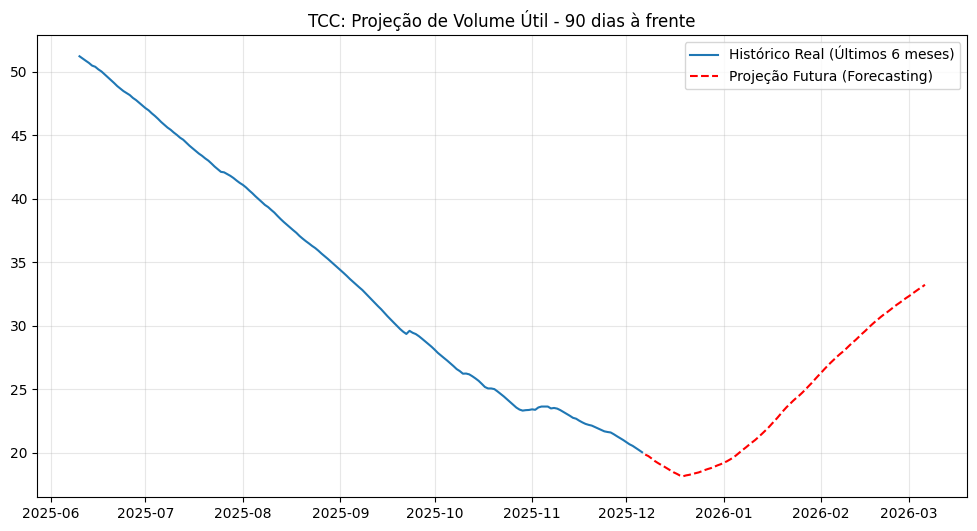

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import warnings

# Silenciando avisos para um output limpo no Grid Search
warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO GLOBAL ---
VALIDATION_SIZE = 90
N_SPLITS = 5
COL_VOL = "Volume Útil Armazenado (%)"
COL_VN = "Vazão Natural (m³/s)"
COL_VJ = "Vazão Jusante (m³/s)"  # Nova variável exógena
LAGS_CICLO = 2

# =============================================================================
# 1. FUNÇÕES AUXILIARES
# =============================================================================
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            vals = vals[(vals >= vals.quantile(0.10)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature_array(index, curva_clim):
    days = index.dayofyear
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])

def criar_feat_fourier(index):
    dp = DeterministicProcess(
        index=index, constant=True, order=1, seasonal=False, 
        additional_terms=[CalendarFourier("YE", 2)], drop=True
    )
    return dp.in_sample()

def criar_lags(series, lags):
    df = pd.DataFrame(index=series.index)
    for l in range(1, lags + 1):
        df[f'lag_{l}'] = series.shift(l)
    return df

# =============================================================================
# 2. CLASSE RESERVOIR FORECASTER (COM JUSANTE E FORECAST FUTURO)
# =============================================================================
class ReservoirForecaster:
    def __init__(self, config):
        self.cfg = config
        self.models = {}
        self.scalers = {}
        self.history = {} 
        self.vol_features_ = []

    def _train_flow_model(self, df_train, col_name, prefix):
        """Treina modelo de vazão (Natural ou Jusante) usando Sazonalidade + ML no Resíduo."""
        y = df_train[col_name]
        
        # 1. Climatologia
        clim_curve = calcular_climatologia_robusta(df_train, col_name)
        self.history[f'{prefix}_clim'] = clim_curve
        
        # 2. Resíduo via Fourier (Tendência Matemática)
        X_math = criar_feat_fourier(df_train.index)
        model_math = LinearRegression()
        model_math.fit(X_math, y)
        self.models[f'{prefix}_math'] = model_math
        
        residuo = y - model_math.predict(X_math)
        
        # 3. ML no Ciclo (Resíduo)
        X_lags = criar_lags(residuo, LAGS_CICLO).dropna()
        y_target = residuo.loc[X_lags.index]
        
        model_cycle = KNeighborsRegressor(n_neighbors=5) 
        model_cycle.fit(X_lags, y_target)
        self.models[f'{prefix}_cycle'] = model_cycle
        
        return residuo.tail(LAGS_CICLO).values

    def fit(self, df_train):
        """Treina todos os submodelos (Vazões e Volume)."""
        # Treina modelos de vazão (sempre treinamos para poder prever o futuro recursivamente)
        self.last_res_vn = self._train_flow_model(df_train, COL_VN, 'vn')
        self.last_res_vj = self._train_flow_model(df_train, COL_VJ, 'vj')
        
        # Prepara features do Volume
        y = df_train[COL_VOL]
        X = pd.DataFrame(index=df_train.index)
        X['vol_lag1'] = df_train[COL_VOL].shift(1)
        
        if self.cfg.get('use_diff1', True):
            X['vol_diff1'] = df_train[COL_VOL].shift(1) - df_train[COL_VOL].shift(2)

        if self.cfg.get('use_diff2', True):
            X['vol_diff2'] = df_train[COL_VOL].shift(2) - df_train[COL_VOL].shift(1)
        
        # Ativação de Exógenas via Config
        if self.cfg.get('use_vn', True):
            X['vn_input'] = df_train[COL_VN]
        if self.cfg.get('use_vj', True):
            X['vj_input'] = df_train[COL_VJ]
            
        if self.cfg.get('use_vol_clim', True):
            self.history['vol_clim'] = calcular_climatologia_robusta(df_train, COL_VOL)
            X['vol_clim'] = get_clim_feature_array(df_train.index, self.history['vol_clim'])

        X_full = X.dropna()
        self.vol_features_ = X_full.columns.tolist()
        
        # Scaling e Treino do Volume
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_full)
        self.scalers['vol'] = scaler
        
        model_vol = self.cfg['model_volume']
        model_vol.fit(X_scaled, y.loc[X_full.index])
        self.models['volume'] = model_vol
        
        # Salva estado para o forecast futuro
        self.last_vol_data = df_train[COL_VOL].tail(3).values.tolist()
        self.last_date = df_train.index[-1]

    def _predict_loop(self, dates, start_vol_buffer, start_res_vn, start_res_vj):
        """Loop recursivo para prever N dias."""
        preds_vol = []
        curr_vol = list(start_vol_buffer)
        curr_res_vn = list(start_res_vn)
        curr_res_vj = list(start_res_vj)

        for date in dates:
            # --- 1. PREVER VAZÕES (Recursivo) ---
            def predict_single_flow(prefix, res_buffer):
                base = get_clim_feature_array(pd.DatetimeIndex([date]), self.history[f'{prefix}_clim'])[0]
                lags = np.array(res_buffer[-LAGS_CICLO:][::-1])
                res_pred = self.models[f'{prefix}_cycle'].predict(pd.DataFrame([lags], columns=[f'lag_{k}' for k in range(1, LAGS_CICLO+1)]))[0]
                
                # Lógica de Damping
                if self.cfg.get('cycle_logic') == 'damping_specific' and res_pred > 0:
                    res_pred *= 0.2 if (res_pred - res_buffer[-1] > 0) else 0.8
                
                return max(0, base + res_pred), res_pred

            vn_val, vn_res = predict_single_flow('vn', curr_res_vn)
            vj_val, vj_res = predict_single_flow('vj', curr_res_vj)
            curr_res_vn.append(vn_res)
            curr_res_vj.append(vj_res)

            # --- 2. PREVER VOLUME ---
            feat_dict = {'vol_lag1': curr_vol[-1]}
            if 'vol_diff1' in self.vol_features_: feat_dict['vol_diff1'] = curr_vol[-1] - curr_vol[-2]
            if 'vol_diff2' in self.vol_features_: feat_dict['vol_diff2'] = curr_vol[-1] - curr_vol[-2]
            if 'vn_input' in self.vol_features_: feat_dict['vn_input'] = vn_val
            if 'vj_input' in self.vol_features_: feat_dict['vj_input'] = vj_val
            if 'vol_clim' in self.vol_features_: 
                feat_dict['vol_clim'] = get_clim_feature_array(pd.DatetimeIndex([date]), self.history['vol_clim'])[0]

            input_df = pd.DataFrame([feat_dict])[self.vol_features_]
            input_scaled = self.scalers['vol'].transform(input_df)
            pred_v = self.models['volume'].predict(input_scaled)[0]
            
            preds_vol.append(pred_v)
            curr_vol.append(pred_v)
            curr_vol.pop(0)
            
        return preds_vol

    def forecast(self, days):
        """Faz a previsão para o futuro além dos dados conhecidos."""
        future_dates = pd.date_range(start=self.last_date + pd.Timedelta(days=1), periods=days)
        return self._predict_loop(future_dates, self.last_vol_data, self.last_res_vn, self.last_res_vj)

    def evaluate(self, df):
        """Validação cruzada temporal."""
        tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VALIDATION_SIZE)
        scores = []
        for train_idx, test_idx in tscv.split(df):
            self.fit(df.iloc[train_idx])
            buffer_vol = df.iloc[train_idx][COL_VOL].tail(3).values
            preds = self._predict_loop(df.iloc[test_idx].index, buffer_vol, self.last_res_vn, self.last_res_vj)
            scores.append(np.sqrt(mean_squared_error(df.iloc[test_idx][COL_VOL], preds)))
        return np.mean(scores)

# =============================================================================
# 3. EXECUÇÃO: GRID SEARCH + FORECAST FINAL
# =============================================================================

# Supondo que 'df' já foi carregado via import_dataframe()
# df = import_dataframe() 

param_grid = {
    'use_vn': [True],
    'use_vj': [True], # TESTA SE JUSANTE AJUDA OU ATRAPALHA
    'cycle_logic': ['damping_specific'],
    'model_volume': [LinearRegression(), Ridge(alpha=1.0)],
    'use_vol_clim': [True],
    'use_diff2': [True, False],
    'use_diff1' : [True, False]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

results = []
for config in combinations:
    try:
        model = ReservoirForecaster(config)
        rmse = model.evaluate(df)
        config['rmse'] = rmse
        results.append(config)
        print(f"Config: {config} | RMSE: {rmse:.4f}")
    except Exception as e: print(f"Erro: {e}")

# --- FINALIZAÇÃO: O FORECAST PARA O TCC ---
best_cfg = pd.DataFrame(results).sort_values('rmse').iloc[0].to_dict()
del best_cfg['rmse'] # Remove a métrica para não quebrar a classe

final_model = ReservoirForecaster(best_cfg)
final_model.fit(df) # Treina no dataset inteiro (2025 completo)

# Previsão para os próximos 90 dias (Futuro desconhecido)
horizonte = 90
preds_futuras = final_model.forecast(horizonte)

# Plot Final
plt.figure(figsize=(12, 6))
plt.plot(df[COL_VOL].tail(180), label="Histórico Real (Últimos 6 meses)")
future_dates = pd.date_range(start=df.index[-1], periods=horizonte+1)[1:]
plt.plot(future_dates, preds_futuras, label="Projeção Futura (Forecasting)", color='red', linestyle='--')
plt.title(f"TCC: Projeção de Volume Útil - {horizonte} dias à frente")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

######### AVALIANDO PRA VERMOS, COMO FICOU O REAL

In [28]:
import datetime
index = [df.tail(1).index[0] + datetime.timedelta(days=i) for i in range(1,91)]
futuro = pd.DataFrame(data = preds_futuras, index = index)
real = pd.read_csv('dados_sabesp_cantareira_historico (1).csv', sep = ';', decimal = ',')
real.set_index('Data', inplace = True)
real = real['Volume Útil Armazenado (%)']

In [43]:
mean_absolute_error(futuro.iloc[0:23].values, real.iloc[-23:].values), mean_squared_error(futuro.iloc[0:23].values, real.iloc[-23:].values)**0.5

(1.6129913414195238, 1.8235708495865142)

Data
07/12/2025    19.86594
08/12/2025    19.70340
09/12/2025    19.67831
10/12/2025    19.86890
11/12/2025    20.06075
12/12/2025    20.04391
13/12/2025    20.09401
14/12/2025    20.36207
15/12/2025    20.55395
16/12/2025    20.57622
17/12/2025    20.68907
18/12/2025    20.70803
19/12/2025    20.82864
20/12/2025    20.89934
21/12/2025    20.87728
22/12/2025    20.85695
23/12/2025    20.76412
24/12/2025    20.60176
25/12/2025    20.45381
26/12/2025    20.35090
27/12/2025    20.27806
28/12/2025    20.17940
29/12/2025    20.10085
Name: Volume Útil Armazenado (%), dtype: float64

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO GLOBAL ---
VALIDATION_SIZE = 90
N_SPLITS = 5
COL_VOL = "Volume Útil Armazenado (%)"
COL_VN = "Vazão Natural (m³/s)"
COL_VJ = "Vazão Jusante (m³/s)" # Nova coluna
LAGS_CICLO = 2

# [Funções auxiliares calcular_climatologia_robusta, get_clim_feature_array e criar_feat_fourier permanecem as mesmas]

class ReservoirForecaster:
    def __init__(self, config):
        self.cfg = config
        self.models = {}
        self.scalers = {}
        self.history = {} 
        self.vol_features_ = []

    def _train_flow_generic(self, df_train, col_name, prefix):
        """Treina modelo de vazão (Natural ou Jusante) usando Climatologia + Fourier Residual."""
        y = df_train[col_name]
        
        # 1. Climatologia
        clim_curve = calcular_climatologia_robusta(df_train, col_name)
        self.history[f'{prefix}_clim'] = clim_curve
        
        # 2. Resíduo via Fourier
        X_math = criar_feat_fourier(df_train.index)
        model_math = LinearRegression()
        model_math.fit(X_math, y)
        self.models[f'{prefix}_math'] = model_math
        
        y_math_clean = pd.Series(model_math.predict(X_math), index=y.index)
        residuo = y - y_math_clean
        
        # 3. ML no Resíduo
        X_lags = criar_lags(residuo, LAGS_CICLO).dropna()
        y_target = residuo.loc[X_lags.index]
        
        model_cycle = KNeighborsRegressor(n_neighbors=5) # Pode vir do config se desejar
        model_cycle.fit(X_lags, y_target)
        self.models[f'{prefix}_cycle'] = model_cycle
        
        return residuo.tail(LAGS_CICLO).values

    def fit(self, df_train):
        """Treina todos os componentes baseados na configuração."""
        # Treina fluxos se habilitados
        self.last_resid_vn = self._train_flow_generic(df_train, COL_VN, 'vn')
        self.last_resid_vj = self._train_flow_generic(df_train, COL_VJ, 'vj')

        # Preparação do Volume
        y = df_train[COL_VOL]
        X = pd.DataFrame(index=df_train.index)
        X['vol_lag1'] = df_train[COL_VOL].shift(1)
        
        if self.cfg.get('use_diff1', True):
            X['vol_diff'] = df_train[COL_VOL].shift(1) - df_train[COL_VOL].shift(2)
            
        # Inclusão condicional de Exógenas
        if self.cfg.get('use_vn', True):
            X['vn_input'] = df_train[COL_VN]
        if self.cfg.get('use_vj', True):
            X['vj_input'] = df_train[COL_VJ]

        X_full = X.dropna()
        self.vol_features_ = X_full.columns.tolist()
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_full)
        self.scalers['vol'] = scaler
        
        model_vol = self.cfg['model_volume']
        model_vol.fit(X_scaled, y.loc[X_full.index])
        self.models['volume'] = model_vol
        
        # Salva estado final para previsões futuras (out-of-sample)
        self.last_vol_values = df_train[COL_VOL].tail(3).values.tolist()
        self.last_date = df_train.index[-1]

    def _predict_recursive(self, dates, initial_vol_buffer, initial_resid_vn, initial_resid_vj):
        """Núcleo da previsão recursiva."""
        preds_vol = []
        curr_vol = list(initial_vol_buffer)
        curr_res_vn = list(initial_resid_vn)
        curr_res_vj = list(initial_resid_vj)

        for date in dates:
            # --- 1. PREVER VAZÕES (VN e VJ) ---
            def get_flow_pred(prefix, curr_res_list):
                base = get_clim_feature_array(pd.DatetimeIndex([date]), self.history[f'{prefix}_clim'])[0]
                lags = np.array(curr_res_list[-LAGS_CICLO:][::-1])
                res_pred = self.models[f'{prefix}_cycle'].predict(pd.DataFrame([lags], columns=[f'lag_{k}' for k in range(1, LAGS_CICLO+1)]))[0]
                
                # Lógica de Damping se houver
                if self.cfg.get('cycle_logic') == 'damping_specific' and res_pred > 0:
                    last_r = curr_res_list[-1]
                    res_pred *= 0.2 if (res_pred - last_r > 0) else 0.8
                
                flow = max(0, base + res_pred)
                return flow, res_pred

            vn_val, vn_res = get_flow_pred('vn', curr_res_vn)
            vj_val, vj_res = get_flow_pred('vj', curr_res_vj)
            
            curr_res_vn.append(vn_res)
            curr_res_vj.append(vj_res)

            # --- 2. PREVER VOLUME ---
            feat_dict = {'vol_lag1': curr_vol[-1]}
            if 'vol_diff' in self.vol_features_:
                feat_dict['vol_diff'] = curr_vol[-1] - curr_vol[-2]
            if 'vn_input' in self.vol_features_:
                feat_dict['vn_input'] = vn_val
            if 'vj_input' in self.vol_features_:
                feat_dict['vj_input'] = vj_val

            input_df = pd.DataFrame([feat_dict])[self.vol_features_]
            input_scaled = self.scalers['vol'].transform(input_df)
            
            pred_v = self.models['volume'].predict(input_scaled)[0]
            preds_vol.append(pred_v)
            
            curr_vol.append(pred_v)
            curr_vol.pop(0)

        return preds_vol

    def forecast(self, horizon_days):
        """Gera previsões para o futuro (além dos dados de treino)."""
        future_dates = pd.date_range(start=self.last_date + pd.Timedelta(days=1), periods=horizon_days)
        return self._predict_recursive(future_dates, self.last_vol_values, self.last_resid_vn, self.last_resid_vj)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO GLOBAL ---
VALIDATION_SIZE = 90
N_SPLITS = 5
COL_VOL = "Volume Útil Armazenado (%)"
COL_VN = "Vazão Natural (m³/s)"
LAGS_CICLO = 2
LAGS_VOLUME = 1

# =============================================================================
# 1. FUNÇÕES AUXILIARES
# =============================================================================
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            vals = vals[(vals >= vals.quantile(0.10)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature_array(index, curva_clim):
    days = index.dayofyear
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])

def criar_feat_fourier(index):
    # Cria features determinísticas (Tendência + Sazonalidade Anual)
    dp = DeterministicProcess(
        index=index, constant=True, order=1, seasonal=False, 
        additional_terms=[CalendarFourier("YE", 2)], drop=True
    )
    return dp.in_sample()

def criar_lags(series, lags):
    df = pd.DataFrame(index=series.index)
    for l in range(1, lags + 1):
        df[f'lag_{l}'] = series.shift(l)
    return df

# =============================================================================
# 2. CLASSE GENERALISTA (COM SUPORTE A VOLUME HÍBRIDO)
# =============================================================================
class ReservoirForecaster:
    def __init__(self, config):
        self.cfg = config
        self.models = {}
        self.scalers = {}
        self.history = {} 
        self.vol_features_ = [] 

    def _train_flow(self, df_train):
        y = df_train[COL_VN]
        
        # 1. Climatologia (Base)
        clim_curve = calcular_climatologia_robusta(df_train, COL_VN)
        self.history['flow_clim'] = clim_curve
        
        # 2. Estratégia: Extração de Resíduo via Fourier
        X_math = criar_feat_fourier(df_train.index)
        model_math = LinearRegression()
        model_math.fit(X_math, y)
        
        y_math_clean = pd.Series(model_math.predict(X_math), index=y.index)
        residuo = y - y_math_clean
        
        # 3. Treina ML no Resíduo (Ciclo)
        X_lags = criar_lags(residuo, LAGS_CICLO).dropna()
        y_target = residuo.loc[X_lags.index]
        
        model_cycle = self.cfg['model_flow_cycle']
        model_cycle.fit(X_lags, y_target)
        self.models['flow_cycle'] = model_cycle
        
        return residuo.tail(LAGS_CICLO).values

    def _train_volume(self, df_train):
        y = df_train[COL_VOL]
        X = pd.DataFrame(index=df_train.index)
        
        # --- Feature Engineering Dinâmica ---
        X['vol_lag1'] = df_train[COL_VOL].shift(1)
        
        if self.cfg.get('use_diff1', True):
            X['vol_diff'] = df_train[COL_VOL].shift(1) - df_train[COL_VOL].shift(2)
            
        if self.cfg.get('use_diff2', False):
            X['vol_diff2'] = (df_train[COL_VOL].shift(1) - df_train[COL_VOL].shift(2)) - \
                             (df_train[COL_VOL].shift(2) - df_train[COL_VOL].shift(3))
        
        # Input Exógeno: Vazão
        X['vazao_input'] = df_train[COL_VN]
        
        # Input Exógeno: Climatologia Volume
        if self.cfg.get('use_vol_clim', False):
            clim_vol = calcular_climatologia_robusta(df_train, COL_VOL)
            self.history['vol_clim'] = clim_vol
            X['vol_clim'] = get_clim_feature_array(df_train.index, clim_vol)

        # Input Exógeno: Tendência Híbrida (Fourier no Volume) -> IMPLEMENTADO AQUI
        if self.cfg.get('vol_hybrid_trend', False):
            # Cria Fourier para o índice de treino
            X_fourier = criar_feat_fourier(df_train.index)
            # Concatena (Pandas alinha pelo índice)
            X = pd.concat([X, X_fourier], axis=1)

        X_full = X.dropna()
        y_train = y.loc[X_full.index]
        
        # Salva features para garantir ordem no predict
        self.vol_features_ = X_full.columns.tolist()
        
        # Scaling
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_full)
        self.scalers['vol'] = scaler
        
        # Treino
        model = self.cfg['model_volume']
        model.fit(X_scaled, y_train)
        self.models['volume'] = model

    def predict(self, df_test, buffer_vol, last_resid_flow):
        preds_vol = []
        
        curr_buffer_vol = list(buffer_vol)
        curr_resid_flow = list(last_resid_flow)
        
        # --- PREPARAÇÃO TREND HÍBRIDA (SE NECESSÁRIO) ---
        # Gera o Fourier para todo o período de teste de uma vez (mais eficiente)
        X_trend_test = None
        if self.cfg.get('vol_hybrid_trend', False):
            X_trend_test = criar_feat_fourier(df_test.index)
        
        for i in range(len(df_test)):
            date = df_test.index[i]
            
            # --- 1. VAZÃO (Híbrida: Base Clim + Ciclo ML) ---
            val_base_clim = get_clim_feature_array(pd.DatetimeIndex([date]), self.history['flow_clim'])[0]
            
            lags_cycle = np.array(curr_resid_flow[-LAGS_CICLO:][::-1])
            cycle_pred = self.models['flow_cycle'].predict(pd.DataFrame([lags_cycle], columns=[f'lag_{k}' for k in range(1, LAGS_CICLO+1)]))[0]
            
            # Damping Logic
            if self.cfg.get('cycle_logic') == 'damping_specific':
                if cycle_pred > 0:
                    last_r = curr_resid_flow[-1]
                    if cycle_pred - last_r > 0:
                        cycle_pred *= 0.2
                    else:
                        cycle_pred *= 0.8
            
            vazao_final = max(0, val_base_clim + cycle_pred)
            curr_resid_flow.append(cycle_pred)
            
            # --- 2. VOLUME ---
            vol_t1 = curr_buffer_vol[-1]
            vol_t2 = curr_buffer_vol[-2]
            vol_t3 = curr_buffer_vol[-3]
            
            # Monta features base (Dicionário não garante ordem, DF garante)
            feat_dict = {'vol_lag1': vol_t1}
            
            if self.cfg.get('use_diff1', True):
                feat_dict['vol_diff'] = vol_t1 - vol_t2
                
            if self.cfg.get('use_diff2', False):
                feat_dict['vol_diff2'] = (vol_t1 - vol_t2) - (vol_t2 - vol_t3)
                
            feat_dict['vazao_input'] = vazao_final
            
            if self.cfg.get('use_vol_clim', False):
                feat_dict['vol_clim'] = get_clim_feature_array(pd.DatetimeIndex([date]), self.history['vol_clim'])[0]
            
            # Cria DataFrame parcial
            input_vol = pd.DataFrame([feat_dict])
            
            # Adiciona Trend Híbrida se necessário
            if self.cfg.get('vol_hybrid_trend', False):
                # Pega a linha correspondente do Fourier pré-calculado
                # Reset index para concatenar lateralmente sem problemas de índice (input_vol tem index 0)
                row_trend = X_trend_test.iloc[[i]].reset_index(drop=True)
                input_vol = pd.concat([input_vol, row_trend], axis=1)
            
            # REORDENAÇÃO CRÍTICA: Garante que as colunas estão na mesma ordem do fit
            # Isso corrige qualquer erro de concatenação ou ordem de dicionário
            input_vol = input_vol[self.vol_features_]
            
            # Scaling
            input_vol_scaled = self.scalers['vol'].transform(input_vol)
            
            # Predict
            pred_vol = self.models['volume'].predict(input_vol_scaled)[0]
            preds_vol.append(pred_vol)
            
            curr_buffer_vol.append(pred_vol)
            curr_buffer_vol.pop(0)
            
        return preds_vol

    def evaluate(self, df):
        tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VALIDATION_SIZE)
        rmse_scores = []
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
            df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
            
            last_resid_flow = self._train_flow(df_train)
            self._train_volume(df_train)
            
            buffer_vol = df_train[COL_VOL].tail(3).values
            preds_vol = self.predict(df_test, buffer_vol, last_resid_flow)
            
            rmse = np.sqrt(mean_squared_error(df_test[COL_VOL], preds_vol))
            rmse_scores.append(rmse)
        
        return np.mean(rmse_scores)

# =============================================================================
# 3. EXECUÇÃO DO GRID SEARCH
# =============================================================================

param_grid = {
    # Modelo Vazão (Fixo na sua melhor configuração)
    'model_flow_cycle': [KNeighborsRegressor(n_neighbors=5), RandomForestRegressor(max_depth=3), RandomForestRegressor(max_depth=5)],
    'cycle_logic': ['damping_specific', None], 
    
    # Modelo Volume (Variações)
    'model_volume': [LinearRegression(), Ridge(alpha=1.0)],
    'use_diff1': [True, False],
    'use_diff2': [True, False],      
    'use_vol_clim': [True, False],   
    
    # NOVA FEATURE PARA TESTE
    'vol_hybrid_trend': [True, False] # Testa se incluir Fourier direto no volume ajuda
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total de configurações a testar: {len(combinations)}")
print("=== INICIANDO GRID SEARCH ===")

results = []

for i, config in enumerate(combinations):
    try:
        cfg_run = config.copy()
        forecaster = ReservoirForecaster(cfg_run)
        rmse = forecaster.evaluate(df)
        
        res = config.copy()
        res['rmse'] = rmse
        # Converter objetos para string para o DataFrame ficar legível
        res['model_volume'] = str(config['model_volume'])
        res['model_flow_cycle'] = str(config['model_flow_cycle'])
        res['cycle_logic'] = str(config['cycle_logic'])
        res['use_diff1'] = str(config['use_diff1'])
        res['use_diff2'] = str(config['use_diff2'])
        res['use_vol_clim'] = str(config['use_vol_clim'])
        res['vol_hybrid_trend'] = str(config['vol_hybrid_trend'])
        
        results.append(res)
        print(f"Iter {i+1}: RMSE={rmse:.4f} | Diff2={config['use_diff2']} | VolClim={config['use_vol_clim']} | HybridTrend={config['vol_hybrid_trend']}")
        
    except Exception as e:
        print(f"Erro na config {i}: {e}")
        # raise e # Descomente para debugar erro completo

# --- ANÁLISE ---
df_results = pd.DataFrame(results).sort_values(by='rmse')
print("\n=== TOP 5 MELHORES CONFIGURAÇÕES ===")
print(df_results.head(5))

Total de configurações a testar: 192
=== INICIANDO GRID SEARCH ===
Iter 1: RMSE=3.5178 | Diff2=True | VolClim=True | HybridTrend=True
Iter 2: RMSE=2.5276 | Diff2=True | VolClim=True | HybridTrend=False
Iter 3: RMSE=3.5035 | Diff2=True | VolClim=False | HybridTrend=True
Iter 4: RMSE=2.1211 | Diff2=True | VolClim=False | HybridTrend=False
Iter 5: RMSE=3.4265 | Diff2=False | VolClim=True | HybridTrend=True
Iter 6: RMSE=2.5667 | Diff2=False | VolClim=True | HybridTrend=False
Iter 7: RMSE=3.4093 | Diff2=False | VolClim=False | HybridTrend=True
Iter 8: RMSE=2.1685 | Diff2=False | VolClim=False | HybridTrend=False
Iter 9: RMSE=3.3256 | Diff2=True | VolClim=True | HybridTrend=True
Iter 10: RMSE=2.6213 | Diff2=True | VolClim=True | HybridTrend=False
Iter 11: RMSE=3.3050 | Diff2=True | VolClim=False | HybridTrend=True
Iter 12: RMSE=2.2389 | Diff2=True | VolClim=False | HybridTrend=False
Iter 13: RMSE=3.3215 | Diff2=False | VolClim=True | HybridTrend=True
Iter 14: RMSE=2.6187 | Diff2=False | VolC

In [ ]:

# Testar modelo com diff de volume e diff2
# Testar modelos considerando calculo normal de modelo hibrido para vazao 
# Testar modelo de volume tentando fazer modelo hibrido tambem 
# Testar modelo de climatologia robusta na vazao
# Testar fazeer modelo para calcular tendencia e sazonalidade da vazao, dai montar um modelo de ciclo para o residuo e depois, no y final qeu seria a vazao, ao inves de fazer a tendencia/sazonalidade predita + o ciclo, fazer a climatologia robusta + o ciclo
# Testar aquelas correções para vazao (no seu ciclo, como fiz no codigo que mandei).
# Nem considerar vazao jusante, só natural.
# Testar adicionar media historica no volume
# Testar adicionar sazonalidade e tendencia no modelo de volume (talvez fazer modelo hibrido, um para tendencia e sazonalidade e outro para as outras variáveis, ao final, usar a saida dos dois para um outro modelo, stacking)
# Em todos considerar scalling dos dados de entrada.

# Usando vazao com fator de correcao.

Falta fazer gridsearch iterando varios modelos e parametros inclusive esse fator.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
VALIDATION_SIZE = 90
LAGS_VAZAO = 2  # Lags para o modelo ML de vazão
LAGS_VOLUME = 1

# Supondo df já carregado
# df = ... 

# --- 1. FUNÇÕES: CLIMATOLOGIA (Feature 1) ---
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        # Filtro simples de dias
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            # Remove outliers (10% - 90%)
            vals = vals[(vals >= vals.quantile(0.10)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature(index, curva_clim):
    """Retorna array com valores da climatologia para as datas do index"""
    days = index.dayofyear
    # Ajuste para bissexto > 366 (se houver erro, usa o ultimo valor)
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])

# --- 2. FUNÇÕES: MODELO ML DE VAZÃO (Feature 2) ---
def criar_feat_fourier(index):
    dp = DeterministicProcess(index=index, constant=True, order=1, 
                              additional_terms=[CalendarFourier("YE", 2)], drop=True)
    return dp.in_sample()

def criar_lags(series, lags):
    df_lags = pd.DataFrame(index=series.index)
    for l in range(1, lags+1):
        df_lags[f'lag_{l}'] = series.shift(l)
    return df_lags

def treinar_modelo_vazao_ml(df_train, col_target):
    # 1. Tendência
    y = df_train[col_target]
    X_trend = criar_feat_fourier(df_train.index)
    
    # Modelo de Tendência (Lasso para ser mais robusto)
    m_trend = Lasso(alpha=0.5)
    m_trend.fit(X_trend, y)
    trend_pred = pd.Series(m_trend.predict(X_trend), index=y.index)
    
    # 2. Resíduos
    resid = y - trend_pred
    X_resid = criar_lags(resid, LAGS_VAZAO).dropna()
    y_resid = resid.loc[X_resid.index]
    
    # Modelo de Resíduos (KNN ou RF)
    m_resid = KNeighborsRegressor(n_neighbors=10) # Aumentei vizinhos para suavizar
    m_resid.fit(X_resid, y_resid)
    
    last_resids = resid.tail(LAGS_VAZAO).values
    return m_trend, m_resid, last_resids

# --- 3. FUNÇÃO: MODELO DE VOLUME (O "JUIZ") ---
def treinar_modelo_volume_final(df_train, col_vol, col_vn, curva_clim, m_trend_vn, m_resid_vn):
    """
    Treina o volume usando:
    1. Lags do Volume
    2. Feature Vazão Climatologia
    3. Feature Vazão ML (In-Sample Prediction)
    """
    y = df_train[col_vol]
    
    # --- Engenharia de Features Dinâmicas ---
    X = pd.DataFrame(index=df_train.index)
    X['vol_lag1'] = df_train[col_vol].shift(1)
    X['vol_diff'] = df_train[col_vol].shift(1) - df_train[col_vol].shift(2)
    
    # --- Feature Exógena 1: Climatologia ---
    X['feat_vazao_clim'] = get_clim_feature(df_train.index, curva_clim)
    
    # --- Feature Exógena 2: Modelo ML (Predição In-Sample) ---
    # Recriamos a previsão que o modelo ML faria no treino para o Volume aprender a confiar (ou não) nele
    X_trend = criar_feat_fourier(df_train.index)
    trend_in = m_trend_vn.predict(X_trend)
    
    # Resíduos in-sample (aproximado via lags reais para treinar rápido)
    resid_real = df_train[col_vn] - trend_in
    X_resid_lags = criar_lags(resid_real, LAGS_VAZAO) # Lags reais
    # Para simplificar e evitar vazamento total, vamos usar a Vazão Real como proxy do "Melhor ML Possível"
    # ou usar a predição real. Vamos usar a predição in-sample do modelo:
    resid_pred_in = m_resid_vn.predict(X_resid_lags.fillna(0)) 
    
    X['feat_vazao_ml'] = trend_in + resid_pred_in
    
    # Drop NaNs gerados pelos lags
    X_full = X.dropna()
    y_train = y.loc[X_full.index]
    
    model_vol = LinearRegression()
    model_vol.fit(X_full, y_train)
    
    return model_vol, X_full.columns

# --- 4. LOOP DE VALIDAÇÃO ---
tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)
resultados = []

print("=== INICIANDO MODELO HÍBRIDO DUPLO (CLIM + ML) ===\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
    
    # A. Treinar Climatologia
    curva_clim = calcular_climatologia_robusta(df_train, nome_coluna_vazao_natural)
    
    # B. Treinar Modelo Vazão ML
    m_vn_trend, m_vn_resid, last_resids_vn = treinar_modelo_vazao_ml(df_train, nome_coluna_vazao_natural)
    
    # C. Treinar Modelo Volume (Com as 2 features)
    model_vol, col_names = treinar_modelo_volume_final(
        df_train, nome_coluna_volume, nome_coluna_vazao_natural, 
        curva_clim, m_vn_trend, m_vn_resid
    )
    
    # Mostrar pesos no primeiro fold
    if fold == 0:
        coefs = pd.Series(model_vol.coef_, index=col_names)
        print("--- PESOS QUE O MODELO DE VOLUME DEU ---")
        print(coefs.sort_values(ascending=False))
        print("Note: Se 'feat_vazao_clim' for maior que 'feat_vazao_ml', o modelo confia mais na média histórica.\n")

    # --- PREVISÃO RECURSIVA ---
    # Preparação
    X_trend_test_vn = criar_feat_fourier(df_test.index)
    buffer_vols = list(df_train[nome_coluna_volume].tail(3).values)
    hist_resid_vn = list(last_resids_vn)
    
    preds_vol = []
    
    # Listas para guardar as features usadas (para plotar depois)
    log_feat_clim = []
    log_feat_ml = []
    
    for i in range(len(df_test)):
        date = df_test.index[i]
        
        # 1. Feature Climatologia
        val_clim = get_clim_feature(pd.DatetimeIndex([date]), curva_clim)[0]
        
        # 2. Feature ML Recursivo
        # a. Trend
        val_trend = m_vn_trend.predict(X_trend_test_vn.iloc[[i]])[0]
        # b. Resid
        lags_resid = np.array(hist_resid_vn[-LAGS_VAZAO:][::-1])
        val_resid = m_vn_resid.predict(pd.DataFrame([lags_resid], columns=[f'lag_{k}' for k in range(1,LAGS_VAZAO+1)]))[0]
        
        val_ml = val_trend + val_resid
        if val_ml < 0: val_ml = 0 # Trava física
        
        # Atualiza histórico de resíduo do ML
        hist_resid_vn.append(val_resid)
        
        # Logs para plot
        log_feat_clim.append(val_clim)
        log_feat_ml.append(val_ml)
        
        # 3. Prever Volume
        vol_t1 = buffer_vols[-1]
        vol_diff = vol_t1 - buffer_vols[-2]
        
        # Monta input para o modelo de volume (MESMA ORDEM DO TREINO)
        # Colunas: ['vol_lag1', 'vol_diff', 'feat_vazao_clim', 'feat_vazao_ml']
        input_vol = pd.DataFrame({
            'vol_lag1': [vol_t1],
            'vol_diff': [vol_diff],
            'feat_vazao_clim': [val_clim],
            'feat_vazao_ml': [val_ml]
        })
        
        pred_vol = model_vol.predict(input_vol)[0]
        preds_vol.append(pred_vol)
        
        # Atualiza buffer volume
        buffer_vols.append(pred_vol)
        buffer_vols.pop(0)

    # --- AVALIAÇÃO ---
    rmse = np.sqrt(mean_squared_error(df_test[nome_coluna_volume], preds_vol))
    resultados.append(rmse)
    
    print(f"Fold {fold+1} RMSE: {rmse:.4f}")
    
    # Plot Diagnóstico
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Gráfico 1: Volume
    ax[0].plot(df_test.index, df_test[nome_coluna_volume], label='Real', color='navy')
    ax[0].plot(df_test.index, preds_vol, label='Previsto Híbrido', color='orange', linestyle='--')
    ax[0].set_title(f"Volume - Fold {fold+1}")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Gráfico 2: Batalha das Features de Vazão
    ax[1].plot(df_test.index, df_test[nome_coluna_vazao_natural], label='Vazão REAL (Alvo)', color='black', alpha=0.3, linewidth=3)
    ax[1].plot(df_test.index, log_feat_clim, label='Feature: Climatologia', color='green')
    ax[1].plot(df_test.index, log_feat_ml, label='Feature: Modelo ML', color='red', linestyle=':')
    ax[1].set_title("Inputs Exógenos: Climatologia vs ML")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\nRMSE Médio Final: {np.mean(resultados):.4f}")

# USANDO SO CLIMATOLOGIA DA VAZAO

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from sklearn.metrics import mean_squared_error
import warnings
import matplotlib.pyplot as plt

# Ignore warnings
warnings.filterwarnings('ignore', message='.*deprecated.*', category=DeprecationWarning)

# --- 1. CONFIGURAÇÃO E DADOS ---
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
nome_coluna_vazao_jusante = "Vazão Jusante (m³/s)"

# Simulação de carga (Substitua pelo seu import)
# df = import_dataframe() 
# df[(df['Data']<='2014-03-01')|(df['Data']>='2016-02-15')]
# df.set_index("Data", inplace=True)

# Supondo que df já esteja carregado no seu ambiente:
# Certifique-se que o índice é datetime

VALIDATION_SIZE = 90
LAGS_VOLUME = 1

# --- 2. FUNÇÕES AUXILIARES ---

def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    """
    Calcula a média histórica para cada dia do ano (1-366),
    usando uma janela deslizante e removendo outliers (quantis).
    """
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    
    climatologia = {}
    
    for day in range(1, 367):
        # Janela deslizante para capturar dias vizinhos (suavização)
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        
        # Filtra (considerando dias do ano)
        # Nota: simplificado para não quebrar na virada do ano, mas funcional
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        valores = temp.loc[mask, col_target]
        
        if len(valores) > 0:
            # Remove outliers extremos (anos de seca ou cheia recorde que distorcem a média)
            q_low = valores.quantile(0.10)
            q_high = valores.quantile(0.90)
            valores_filtrados = valores[(valores >= q_low) & (valores <= q_high)]
            
            if len(valores_filtrados) == 0:
                media = valores.mean()
            else:
                media = valores_filtrados.mean()
        else:
            media = 0
            
        climatologia[day] = media
        
    return pd.Series(climatologia, name='climatologia')

def criar_features_deterministicas_volume(index):
    # Usado apenas para features de sazonalidade dentro do modelo de volume
    dp = DeterministicProcess(
        index=index,
        constant=True, order=1,
        additional_terms=[
            # Sazonalidade anual e bienal para ajudar o volume
            Fourier(period=365.25 * 2, order=1),
            CalendarFourier(freq="YE", order=2)
        ],
        drop=True
    )
    return dp.in_sample()

def treinar_modelo_volume(df_train, col_vol, col_vn, model_vol):
    """
    Treina o modelo de Volume.
    IMPORTANTE: Treinamos com a Vazão REAL histórica.
    O modelo aprende a física: "Se entrar X água, o volume sobe Y".
    No teste, nós mentimos para ele entregando a Climatologia no lugar da Vazão Real.
    """
    y = df_train[col_vol]
    
    X_dynamic = pd.DataFrame(index=df_train.index)
    X_dynamic['vol_lag1'] = df_train[col_vol].shift(1)
    
    # 1ª Derivada
    X_dynamic['vol_diff'] = df_train[col_vol].shift(1) - df_train[col_vol].shift(2)
    # 2ª Derivada
    X_dynamic['vol_diff2'] = (df_train[col_vol].shift(1) - df_train[col_vol].shift(2)) - \
                             (df_train[col_vol].shift(2) - df_train[col_vol].shift(3))
    
    # Input Exógeno (Vazão Natural)
    X_dynamic['vazao_n'] = df_train[col_vn] 
    
    # Features Determinísticas (Sazonalidade do Volume)
    X_trend = criar_features_deterministicas_volume(df_train.index)
    
    X_full = pd.concat([X_dynamic, X_trend], axis=1).dropna()
    y_train = y.loc[X_full.index]
    
    model_vol.fit(X_full, y_train)
    return model_vol, X_full

def mostrar_equacao_linear(modelo, nomes_colunas):
    coeficientes = modelo.coef_
    intercepto = modelo.intercept_
    df_params = pd.DataFrame({'Variável': nomes_colunas, 'Peso': coeficientes})
    df_params['Abs'] = df_params['Peso'].abs()
    print("\n=== PESOS DO MODELO DE VOLUME ===")
    print(df_params.sort_values(by='Abs', ascending=False).drop(columns='Abs'))
    print("-" * 30)

# --- 3. LOOP DE VALIDAÇÃO ---

tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)
resultados = []

print("Iniciando Validação Cruzada com CLIMATOLOGIA NA VAZÃO...\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]
    
    print(f"Fold {fold+1}: Teste de {df_test.index[0].date()} a {df_test.index[-1].date()}")

    # =================================================================
    # ETAPA 1: PREPARAÇÃO (Usando dados de TREINO)
    # =================================================================
    
    # A. Calcular Climatologia (A "Previsão" da Vazão)
    # Baseada apenas no histórico disponível até aquele momento (df_train)
    curva_climatologia = calcular_climatologia_robusta(df_train, nome_coluna_vazao_natural, window_days=7)
    
    # B. Treinar Modelo de Volume (Com Vazão Real)
    model_volume = LinearRegression()
    model_volume, X_full_eq = treinar_modelo_volume(
        df_train, nome_coluna_volume, nome_coluna_vazao_natural, model_volume
    )
    if fold == 0: mostrar_equacao_linear(model_volume, X_full_eq.columns)

    # =================================================================
    # ETAPA 2: PREVISÃO RECURSIVA DO VOLUME
    # =================================================================
    
    # Prepara features determinísticas de volume para o futuro (datas de teste)
    X_trend_test_v = criar_features_deterministicas_volume(df_test.index)
    
    # Buffer para cálculo de lags e derivadas do volume
    buffer_vols = list(df_train[nome_coluna_volume].tail(3).values)
    
    preds_volume = []
    preds_vn_utilizada = [] # Para guardar qual vazão (climatologia) foi usada no dia
    
    # LOOP DIA A DIA
    for i in range(len(df_test)):
        current_date = df_test.index[i]
        idx_atual = [current_date]
        
        # --- 1. Obter Vazão Natural (Via Climatologia) ---
        day_of_year = current_date.dayofyear
        # Se for bissexto (366) e a curva foi feita sem tratar, usamos 365 ou tratamos
        if day_of_year > 366: day_of_year = 366 
        
        # O "chute" do modelo para a chuva de hoje é a média histórica
        try:
            vazao_n_input = curva_climatologia.loc[day_of_year]
        except KeyError:
             # Fallback caso dia 366 dê erro
            vazao_n_input = curva_climatologia.iloc[-1]
            
        preds_vn_utilizada.append(vazao_n_input)
        
        # --- 2. Prever Volume ---
        # Recupera valores do buffer (Volume previsto dias anteriores)
        vol_t_1 = buffer_vols[-1] 
        vol_t_2 = buffer_vols[-2] 
        vol_t_3 = buffer_vols[-3] 
        
        # Calcula derivadas
        feat_diff = vol_t_1 - vol_t_2
        feat_diff2 = (vol_t_1 - vol_t_2) - (vol_t_2 - vol_t_3)
        
        # Monta DataFrame Dinâmico
        df_dynamic = pd.DataFrame({
            'vol_lag1':  [vol_t_1],
            'vol_diff':  [feat_diff],
            'vol_diff2': [feat_diff2],
            'vazao_n':   [vazao_n_input] # Aqui entra a CLIMATOLOGIA
        }, index=idx_atual)
        
        # Pega a parte estática (sazonalidade)
        df_static = X_trend_test_v.iloc[[i]]
        
        # Concatena e prevê
        X_vol_input = pd.concat([df_dynamic, df_static], axis=1)
        
        vol_pred = model_volume.predict(X_vol_input)[0]
        preds_volume.append(vol_pred)
        
        # Atualiza Buffer
        buffer_vols.append(vol_pred)
        buffer_vols.pop(0)

    # =================================================================
    # ETAPA 3: AVALIAÇÃO
    # =================================================================
    
    y_true_vol = df_test[nome_coluna_volume]
    y_true_vn = df_test[nome_coluna_vazao_natural]
    
    rmse_vol = np.sqrt(mean_squared_error(y_true_vol, preds_volume))
    rmse_vn_clim = np.sqrt(mean_squared_error(y_true_vn, preds_vn_utilizada))
    
    resultados.append(rmse_vol)
    
    print(f"--- RESULTADOS FOLD {fold+1} ---")
    print(f"[VOLUME] RMSE: {rmse_vol:.4f}")
    print(f"[VAZÃO - CLIMATOLOGIA] RMSE: {rmse_vn_clim:.4f}")
    
    # PLOTAGEM
    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Gráfico 1: Volume
    axs[0].plot(y_true_vol.index, y_true_vol, label='Real', color='navy')
    axs[0].plot(y_true_vol.index, preds_volume, label='Previsto (c/ Climatologia)', color='darkorange', linestyle='--')
    axs[0].set_title(f'Fold {fold+1} - Volume (RMSE: {rmse_vol:.2f})')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)
    
    # Gráfico 2: Vazão (Real vs Climatologia usada)
    axs[1].plot(y_true_vn.index, y_true_vn, label='Vazão Real (Chuva)', color='blue', alpha=0.4)
    axs[1].plot(y_true_vn.index, preds_vn_utilizada, label='Climatologia Usada', color='green', linewidth=2)
    axs[1].set_title(f'Input Exógeno: Climatologia vs Real (RMSE: {rmse_vn_clim:.2f})')
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\nRMSE Médio (Volume): {np.mean(resultados):.4f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
VALIDATION_SIZE = 90
LAGS_VAZAO = 2  # Lags para o modelo ML de vazão
LAGS_VOLUME = 1

# Supondo df já carregado
# df = ... 

# --- 1. FUNÇÕES: CLIMATOLOGIA (Feature 1) ---
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        # Filtro simples de dias
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            # Remove outliers (10% - 90%)
            vals = vals[(vals >= vals.quantile(0.10)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature(index, curva_clim):
    """Retorna array com valores da climatologia para as datas do index"""
    days = index.dayofyear
    # Ajuste para bissexto > 366 (se houver erro, usa o ultimo valor)
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])

# --- 2. FUNÇÕES: MODELO ML DE VAZÃO (Feature 2) ---
def criar_feat_fourier(index):
    dp = DeterministicProcess(index=index, constant=True, order=1, 
                              additional_terms=[CalendarFourier("YE", 2)], drop=True)
    return dp.in_sample()

def criar_lags(series, lags):
    df_lags = pd.DataFrame(index=series.index)
    for l in range(1, lags+1):
        df_lags[f'lag_{l}'] = series.shift(l)
    return df_lags

def treinar_modelo_vazao_ml(df_train, col_target):
    # 1. Tendência
    y = df_train[col_target]
    X_trend = criar_feat_fourier(df_train.index)
    
    # Modelo de Tendência (Lasso para ser mais robusto)
    m_trend = Ridge(alpha=0.5)
    m_trend.fit(X_trend, y)
    trend_pred = pd.Series(m_trend.predict(X_trend), index=y.index)
    
    # 2. Resíduos
    resid = y - trend_pred
    X_resid = criar_lags(resid, LAGS_VAZAO).dropna()
    y_resid = resid.loc[X_resid.index]
    
    # Modelo de Resíduos (KNN ou RF)
    m_resid = KNeighborsRegressor(n_neighbors=10) # Aumentei vizinhos para suavizar
    m_resid.fit(X_resid, y_resid)
    
    last_resids = resid.tail(LAGS_VAZAO).values
    return m_trend, m_resid, last_resids

# --- 3. FUNÇÃO: MODELO DE VOLUME (O "JUIZ") ---
def treinar_modelo_volume_final(df_train, col_vol, col_vn, curva_clim, m_trend_vn, m_resid_vn):
    """
    Treina o volume usando:
    1. Lags do Volume
    2. Feature Vazão Climatologia
    3. Feature Vazão ML (In-Sample Prediction)
    """
    y = df_train[col_vol]
    
    # --- Engenharia de Features Dinâmicas ---
    X = pd.DataFrame(index=df_train.index)
    X['vol_lag1'] = df_train[col_vol].shift(1)
    X['vol_diff'] = df_train[col_vol].shift(1) - df_train[col_vol].shift(2)
    
    # --- Feature Exógena 1: Climatologia ---
    X['feat_vazao_clim'] = get_clim_feature(df_train.index, curva_clim)
    
    # --- Feature Exógena 2: Modelo ML (Predição In-Sample) ---
    # Recriamos a previsão que o modelo ML faria no treino para o Volume aprender a confiar (ou não) nele
    X_trend = criar_feat_fourier(df_train.index)
    trend_in = m_trend_vn.predict(X_trend)
    
    # Resíduos in-sample (aproximado via lags reais para treinar rápido)
    resid_real = df_train[col_vn] - trend_in
    X_resid_lags = criar_lags(resid_real, LAGS_VAZAO) # Lags reais
    # Para simplificar e evitar vazamento total, vamos usar a Vazão Real como proxy do "Melhor ML Possível"
    # ou usar a predição real. Vamos usar a predição in-sample do modelo:
    resid_pred_in = m_resid_vn.predict(X_resid_lags.fillna(0)) 
    
    X['feat_vazao_ml'] = trend_in + resid_pred_in
    
    # Drop NaNs gerados pelos lags
    X_full = X.dropna()
    y_train = y.loc[X_full.index]
    
    model_vol = LinearRegression()
    model_vol.fit(X_full, y_train)
    
    return model_vol, X_full.columns

# --- 4. LOOP DE VALIDAÇÃO ---
tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)
resultados = []

print("=== INICIANDO MODELO HÍBRIDO DUPLO (CLIM + ML) ===\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
    
    # A. Treinar Climatologia
    curva_clim = calcular_climatologia_robusta(df_train, nome_coluna_vazao_natural)
    
    # B. Treinar Modelo Vazão ML
    m_vn_trend, m_vn_resid, last_resids_vn = treinar_modelo_vazao_ml(df_train, nome_coluna_vazao_natural)
    
    # C. Treinar Modelo Volume (Com as 2 features)
    model_vol, col_names = treinar_modelo_volume_final(
        df_train, nome_coluna_volume, nome_coluna_vazao_natural, 
        curva_clim, m_vn_trend, m_vn_resid
    )
    
    # Mostrar pesos no primeiro fold
    if fold == 0:
        coefs = pd.Series(model_vol.coef_, index=col_names)
        print("--- PESOS QUE O MODELO DE VOLUME DEU ---")
        print(coefs.sort_values(ascending=False))
        print("Note: Se 'feat_vazao_clim' for maior que 'feat_vazao_ml', o modelo confia mais na média histórica.\n")

    # --- PREVISÃO RECURSIVA ---
    # Preparação
    X_trend_test_vn = criar_feat_fourier(df_test.index)
    buffer_vols = list(df_train[nome_coluna_volume].tail(3).values)
    hist_resid_vn = list(last_resids_vn)
    
    preds_vol = []
    
    # Listas para guardar as features usadas (para plotar depois)
    log_feat_clim = []
    log_feat_ml = []
    
    for i in range(len(df_test)):
        date = df_test.index[i]
        
        # 1. Feature Climatologia
        val_clim = get_clim_feature(pd.DatetimeIndex([date]), curva_clim)[0]
        
        # 2. Feature ML Recursivo
        # a. Trend
        val_trend = m_vn_trend.predict(X_trend_test_vn.iloc[[i]])[0]
        # b. Resid
        lags_resid = np.array(hist_resid_vn[-LAGS_VAZAO:][::-1])
        val_resid = m_vn_resid.predict(pd.DataFrame([lags_resid], columns=[f'lag_{k}' for k in range(1,LAGS_VAZAO+1)]))[0]
        
        val_ml = val_trend + val_resid
        if val_ml < 0: val_ml = 0 # Trava física
        
        # Atualiza histórico de resíduo do ML
        hist_resid_vn.append(val_resid)
        
        # Logs para plot
        log_feat_clim.append(val_clim)
        log_feat_ml.append(val_ml)
        
        # 3. Prever Volume
        vol_t1 = buffer_vols[-1]
        vol_diff = vol_t1 - buffer_vols[-2]
        
        # Monta input para o modelo de volume (MESMA ORDEM DO TREINO)
        # Colunas: ['vol_lag1', 'vol_diff', 'feat_vazao_clim', 'feat_vazao_ml']
        input_vol = pd.DataFrame({
            'vol_lag1': [vol_t1],
            'vol_diff': [vol_diff],
            'feat_vazao_clim': [val_clim],
            'feat_vazao_ml': [val_ml]
        })
        
        pred_vol = model_vol.predict(input_vol)[0]
        preds_vol.append(pred_vol)
        
        # Atualiza buffer volume
        buffer_vols.append(pred_vol)
        buffer_vols.pop(0)

    # --- AVALIAÇÃO ---
    rmse = np.sqrt(mean_squared_error(df_test[nome_coluna_volume], preds_vol))
    resultados.append(rmse)
    
    print(f"Fold {fold+1} RMSE: {rmse:.4f}")
    
    # Plot Diagnóstico
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Gráfico 1: Volume
    ax[0].plot(df_test.index, df_test[nome_coluna_volume], label='Real', color='navy')
    ax[0].plot(df_test.index, preds_vol, label='Previsto Híbrido', color='orange', linestyle='--')
    ax[0].set_title(f"Volume - Fold {fold+1}")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Gráfico 2: Batalha das Features de Vazão
    ax[1].plot(df_test.index, df_test[nome_coluna_vazao_natural], label='Vazão REAL (Alvo)', color='black', alpha=0.3, linewidth=3)
    ax[1].plot(df_test.index, log_feat_clim, label='Feature: Climatologia', color='green')
    ax[1].plot(df_test.index, log_feat_ml, label='Feature: Modelo ML', color='red', linestyle=':')
    ax[1].set_title("Inputs Exógenos: Climatologia vs ML")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\nRMSE Médio Final: {np.mean(resultados):.4f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
VALIDATION_SIZE = 90
LAGS_RESIDUO = 2  # Lags do "Ciclo" (desvio da média)
LAGS_VOLUME = 1

# Supondo df já carregado
# df = ... 
# Certifique-se que o índice é Datetime

# --- 1. FUNÇÕES: CLIMATOLOGIA (A BASE) ---
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            # Remove outliers (10% - 90%) para pegar o "padrão normal"
            vals = vals[(vals >= vals.quantile(0.10)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature(index, curva_clim):
    """Retorna array com valores da climatologia para as datas do index"""
    days = index.dayofyear
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])

# --- 2. FUNÇÕES: MODELO DE CICLO (ML NOS RESÍDUOS) ---
def criar_lags(series, lags):
    df_lags = pd.DataFrame(index=series.index)
    for l in range(1, lags+1):
        df_lags[f'lag_{l}'] = series.shift(l)
    return df_lags

def treinar_modelo_ciclo(df_train, col_target, curva_clim):
    """
    1. Calcula o erro da climatologia no treino (Real - Climatologia).
    2. Treina um ML para prever esse erro (Ciclo) baseado nos erros passados.
    """
    y_real = df_train[col_target]
    y_clim = get_clim_feature(df_train.index, curva_clim)
    
    # O Alvo do ML é o RESÍDUO (O quanto a climatologia errou)
    residuo = y_real - y_clim 
    
    # Features: Lags do próprio resíduo (Autocorrelação do erro)
    # Ex: Se ontem choveu muito acima da média, hoje tende a chover acima também?
    X_lags = criar_lags(residuo, LAGS_RESIDUO).dropna()
    y_target_resid = residuo.loc[X_lags.index]
    
    # Modelo ML (Random Forest é bom para capturar padrões não lineares no erro)
    # Pode usar KNN também se quiser algo mais suave
    model_resid = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    model_resid.fit(X_lags, y_target_resid)
    
    # Retorna o modelo e os últimos resíduos para iniciar o loop de teste
    last_resids = residuo.tail(LAGS_RESIDUO).values
    return model_resid, last_resids

# --- 3. FUNÇÃO: MODELO DE VOLUME ---
def treinar_modelo_volume(df_train, col_vol, col_vn):
    """
    Treina o modelo físico de Volume.
    Usamos a VAZÃO REAL no treino para ele aprender a física correta:
    (Entrou Água -> Volume Subiu).
    """
    y = df_train[col_vol]
    
    X = pd.DataFrame(index=df_train.index)
    X['vol_lag1'] = df_train[col_vol].shift(1)
    X['vol_diff'] = df_train[col_vol].shift(1) - df_train[col_vol].shift(2)
    
    # Feature Exógena: Vazão Natural (Aqui usamos a REAL para aprender a relação física)
    X['vazao_input'] = df_train[col_vn]
    
    X_full = X.dropna()
    y_train = y.loc[X_full.index]
    
    model_vol = LinearRegression()
    model_vol.fit(X_full, y_train)
    
    return model_vol

# --- 4. LOOP DE VALIDAÇÃO ---
tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)
resultados_vol = []
resultados_vazao = []

print("=== INICIANDO MODELO: CLIMATOLOGIA (BASE) + ML (CICLO) ===\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
    
    # --- ETAPA A: TREINAMENTO ---
    
    # 1. Calcula Climatologia (Base)
    curva_clim = calcular_climatologia_robusta(df_train, nome_coluna_vazao_natural)
    
    # 2. Treina ML para prever o Ciclo (Resíduo da Climatologia)
    m_ciclo, last_resids_cycle = treinar_modelo_ciclo(df_train, nome_coluna_vazao_natural, curva_clim)
    
    # 3. Treina Volume (Aprende a relação Volume <-> Vazão)
    m_volume = treinar_modelo_volume(df_train, nome_coluna_volume, nome_coluna_vazao_natural)
    
    # --- ETAPA B: PREVISÃO RECURSIVA ---
    
    buffer_vols = list(df_train[nome_coluna_volume].tail(3).values)
    hist_resid_cycle = list(last_resids_cycle)
    
    preds_vol = []
    preds_vazao_construida = [] # Para avaliarmos se essa construção ficou boa
    
    for i in range(len(df_test)):
        date = df_test.index[i]
        
        # 1. PREVISÃO DA VAZÃO (HÍBRIDA)
        # Parte 1: Base Climatológica
        val_base = get_clim_feature(pd.DatetimeIndex([date]), curva_clim)[0]
        
        # Parte 2: Ciclo (ML prevê o desvio baseado nos desvios anteriores)
        lags_cycle = np.array(hist_resid_cycle[-LAGS_RESIDUO:][::-1])
        # Reshape para (1, n_features)
        pred_desvio = m_ciclo.predict(pd.DataFrame([lags_cycle], columns=[f'lag_{k}' for k in range(1,LAGS_RESIDUO+1)]))[0]
        
        # Vazão Final = Base + Desvio
        vazao_final = val_base + pred_desvio
        
        # Trava física: Não existe vazão negativa, nem desvio que zere absurdamente se não for seca
        if vazao_final < 0: vazao_final = 0
        
        preds_vazao_construida.append(vazao_final)
        
        # Atualiza o histórico de resíduos com o DESVIO PREVISTO (Recursão)
        hist_resid_cycle.append(pred_desvio)
        
        # 2. PREVISÃO DO VOLUME
        vol_t1 = buffer_vols[-1]
        vol_diff = vol_t1 - buffer_vols[-2]
        
        input_vol = pd.DataFrame({
            'vol_lag1': [vol_t1],
            'vol_diff': [vol_diff],
            'vazao_input': [vazao_final] # Entra a vazão construída
        })
        
        pred_vol = m_volume.predict(input_vol)[0]
        preds_vol.append(pred_vol)
        
        buffer_vols.append(pred_vol)
        buffer_vols.pop(0)

    # --- AVALIAÇÃO ---
    rmse_vol = np.sqrt(mean_squared_error(df_test[nome_coluna_volume], preds_vol))
    rmse_vazao = np.sqrt(mean_squared_error(df_test[nome_coluna_vazao_natural], preds_vazao_construida))
    
    resultados_vol.append(rmse_vol)
    resultados_vazao.append(rmse_vazao)
    
    print(f"Fold {fold+1} | RMSE Volume: {rmse_vol:.4f} | RMSE Vazão (Híbrida): {rmse_vazao:.4f}")
    
    # --- PLOT DETALHADO ---
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Gráfico 1: O Resultado Final (Volume)
    ax[0].plot(df_test.index, df_test[nome_coluna_volume], label='Volume Real', color='navy')
    ax[0].plot(df_test.index, preds_vol, label='Volume Previsto', color='darkorange', linestyle='--')
    ax[0].set_title(f"Previsão de Volume - Fold {fold+1}")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Gráfico 2: Como construímos a vazão?
    ax[1].plot(df_test.index, df_test[nome_coluna_vazao_natural], label='Vazão Real', color='black', alpha=0.3)
    
    # Plota a Climatologia pura (para vermos a base)
    clim_pura = get_clim_feature(df_test.index, curva_clim)
    ax[1].plot(df_test.index, clim_pura, label='Base (Climatologia)', color='green', linestyle=':', linewidth=1)
    
    # Plota a Vazão Final (Base + Ciclo)
    ax[1].plot(df_test.index, preds_vazao_construida, label='Híbrido (Base + Ciclo ML)', color='red', linewidth=1.5)
    
    ax[1].set_title(f"Decomposição da Vazão (RMSE: {rmse_vazao:.2f})")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\nRMSE Médio Final (Volume): {np.mean(resultados_vol):.4f}")
print(f"RMSE Médio Final (Vazão): {np.mean(resultados_vazao):.4f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
VALIDATION_SIZE = 90
LAGS_CICLO = 2  # Lags do resíduo
LAGS_VOLUME = 1

# Supondo df já carregado no ambiente
# df = ... 

# ==============================================================================
# 1. CLIMATOLOGIA (A BASE DE SOMA)
# ==============================================================================
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            # Remove outliers extremos
            vals = vals[(vals >= vals.quantile(0.10)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature(index, curva_clim):
    days = index.dayofyear
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])

# ==============================================================================
# 2. MODELO MATEMÁTICO (PARA EXTRAIR O CICLO/RESÍDUO)
# ==============================================================================
def criar_feat_fourier(index):
    # Cria a base matemática (Tendência Linear + Sazonalidade Perfeita)
    dp = DeterministicProcess(
        index=index, 
        constant=True, 
        order=1, # Tendência Linear
        seasonal=False, 
        additional_terms=[CalendarFourier("YE", 2)], # Fourier ordem 2
        drop=True
    )
    return dp.in_sample()

def treinar_modelo_extracao_residuo(df_train, col_target):
    """
    Treina um modelo Linear/Ridge apenas para capturar a tendência e sazonalidade matemática.
    O objetivo é gerar o resíduo: Real - Matemático.
    """
    y = df_train[col_target]
    X = criar_feat_fourier(df_train.index)
    
    model_math = LinearRegression()
    # model_math = Ridge(alpha=0.5)
    model_math.fit(X, y)
    
    # Gera a curva matemática ("Limpa")
    y_math_clean = pd.Series(model_math.predict(X), index=y.index)
    
    # O CICLO é o que sobrou (Resíduo)
    residuo_ciclo = y - y_math_clean
    
    return model_math, residuo_ciclo

# ==============================================================================
# 3. MODELO ML (APRENDE O PADRÃO DO CICLO)
# ==============================================================================
def criar_lags(series, lags):
    df_lags = pd.DataFrame(index=series.index)
    for l in range(1, lags+1):
        df_lags[f'lag_{l}'] = series.shift(l)
    return df_lags

def treinar_modelo_ciclo_ml(residuo_series):
    """
    Treina o ML para prever o próximo resíduo baseados nos anteriores.
    """
    X_lags = criar_lags(residuo_series, LAGS_CICLO).dropna()
    y_target = residuo_series.loc[X_lags.index]
    
    # Random Forest captura bem a não-linearidade do ruído
    model_ml = KNeighborsRegressor(n_neighbors=5)
    model_ml.fit(X_lags, y_target)
    
    last_resids = residuo_series.tail(LAGS_CICLO).values
    return model_ml, last_resids

# ==============================================================================
# 4. MODELO DE VOLUME (FÍSICO)
# ==============================================================================
def treinar_modelo_volume(df_train, col_vol, col_vn):
    y = df_train[col_vol]
    X = pd.DataFrame(index=df_train.index)
    X['vol_lag1'] = df_train[col_vol].shift(1)
    X['vol_diff'] = df_train[col_vol].shift(1) - df_train[col_vol].shift(2)
    X['vazao_input'] = df_train[col_vn] # Treina com a Real
    
    X_full = X.dropna()
    y_train = y.loc[X_full.index]
    
    model_vol = LinearRegression()
    model_vol.fit(X_full, y_train)
    return model_vol

# ==============================================================================
# 5. LOOP DE VALIDAÇÃO
# ==============================================================================
tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)
resultados_vol = []
resultados_vazao = []

print("=== INICIANDO MODELO: RESÍDUO DE FOURIER + BASE CLIMATOLÓGICA ===\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
    
    # --- A. TREINAMENTO ---
    
    # 1. Base Climatológica (Calculada no Treino)
    curva_clim = calcular_climatologia_robusta(df_train, nome_coluna_vazao_natural)
    
    # 2. Extração do Ciclo (Usando Modelo Matemático Fourier)
    model_math, serie_residuos_treino = treinar_modelo_extracao_residuo(df_train, nome_coluna_vazao_natural)
    
    # 3. Treino do ML no Ciclo
    model_ml_ciclo, last_resids_cycle = treinar_modelo_ciclo_ml(serie_residuos_treino)
    
    # 4. Treino do Volume
    model_vol = treinar_modelo_volume(df_train, nome_coluna_volume, nome_coluna_vazao_natural)
    
    # --- B. PREVISÃO RECURSIVA ---
    
    # Buffer para volume
    buffer_vols = list(df_train[nome_coluna_volume].tail(3).values)
    # Histórico para o ciclo (inicializado com os últimos resíduos REAIS do treino)
    hist_resid_cycle = list(last_resids_cycle)
    
    preds_vol = []
    preds_vazao_hibrida = [] 
    
    for i in range(len(df_test)):
        date = df_test.index[i]
        
        # 1. CALCULAR VAZÃO
        
        # A) Pega a Base (Climatologia)
        val_base_clim = get_clim_feature(pd.DatetimeIndex([date]), curva_clim)[0]
        
        # B) Prevê o Ciclo (Usando o ML treinado nos resíduos do Fourier)
        lags_cycle = np.array(hist_resid_cycle[-LAGS_CICLO:][::-1])
        cycle_pred = model_ml_ciclo.predict(pd.DataFrame([lags_cycle], columns=[f'lag_{k}' for k in range(1,LAGS_CICLO+1)]))[0]
        
        # C) SOMA HÍBRIDA: Climatologia + Ciclo(Fourier)
        vazao_final = val_base_clim + cycle_pred
        
        if vazao_final < 0: vazao_final = 0
        preds_vazao_hibrida.append(vazao_final)
        
        # Atualiza histórico de ciclo com o previsto (Recursão)
        hist_resid_cycle.append(cycle_pred)
        
        # 2. CALCULAR VOLUME
        vol_t1 = buffer_vols[-1]
        vol_diff = vol_t1 - buffer_vols[-2]
        
        input_vol = pd.DataFrame({
            'vol_lag1': [vol_t1],
            'vol_diff': [vol_diff],
            'vazao_input': [vazao_final]
        })
        
        pred_vol = model_vol.predict(input_vol)[0]
        preds_vol.append(pred_vol)
        
        buffer_vols.append(pred_vol)
        buffer_vols.pop(0)

    # --- AVALIAÇÃO ---
    rmse_vol = np.sqrt(mean_squared_error(df_test[nome_coluna_volume], preds_vol))
    rmse_vazao = np.sqrt(mean_squared_error(df_test[nome_coluna_vazao_natural], preds_vazao_hibrida))
    
    resultados_vol.append(rmse_vol)
    
    print(f"Fold {fold+1} | RMSE Volume: {rmse_vol:.4f} | RMSE Vazão: {rmse_vazao:.4f}")
    
    # PLOT
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Gráfico Volume
    ax[0].plot(df_test.index, df_test[nome_coluna_volume], label='Volume Real', color='navy')
    ax[0].plot(df_test.index, preds_vol, label='Volume Previsto', color='darkorange', linestyle='--')
    ax[0].set_title(f"Fold {fold+1} - Volume")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Gráfico Vazão (O Pulo do Gato)
    ax[1].plot(df_test.index, df_test[nome_coluna_vazao_natural], label='Real', color='black', alpha=0.3)
    
    # Mostra a base Climatológica
    clim_base = get_clim_feature(df_test.index, curva_clim)
    ax[1].plot(df_test.index, clim_base, label='Base (Climatologia)', color='green', linestyle=':', linewidth=1)
    
    # Mostra o resultado final
    ax[1].plot(df_test.index, preds_vazao_hibrida, label='Final (Clim + Ciclo ML)', color='red', linewidth=1.5)
    
    ax[1].set_title("Composição da Vazão: Base Climatológica + Ciclo Aprendido via Fourier")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\nRMSE Médio (Volume): {np.mean(resultados_vol):.4f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
VALIDATION_SIZE = 90
LAGS_CICLO = 2  # Lags do resíduo da vazão
LAGS_VOLUME = 1

# Supondo df já carregado no ambiente
# df = ... 

# ==============================================================================
# 1. CLIMATOLOGIA (A BASE DE TUDO)
# ==============================================================================
def calcular_climatologia_robusta(df_train, col_target, window_days=7):
    temp = df_train[[col_target]].copy()
    temp['day_of_year'] = temp.index.dayofyear
    climatologia = {}
    for day in range(1, 367):
        d_min = day - (window_days // 2)
        d_max = day + (window_days // 2)
        mask = (temp['day_of_year'] >= d_min) & (temp['day_of_year'] <= d_max)
        vals = temp.loc[mask, col_target]
        if len(vals) > 0:
            # Remove outliers extremos (10% - 90%)
            vals = vals[(vals >= vals.quantile(0.10)) & (vals <= vals.quantile(0.90))]
            media = vals.mean() if len(vals) > 0 else 0
        else:
            media = 0
        climatologia[day] = media
    return pd.Series(climatologia, name='clim_base')

def get_clim_feature(index, curva_clim):
    """Retorna array com valores da climatologia para as datas do index"""
    days = index.dayofyear
    return np.array([curva_clim.get(d, curva_clim.iloc[-1]) for d in days])

# ==============================================================================
# 2. MODELO MATEMÁTICO (PARA EXTRAIR O CICLO DA VAZÃO)
# ==============================================================================
def criar_feat_fourier(index):
    dp = DeterministicProcess(
        index=index, 
        constant=True, 
        order=1, 
        seasonal=False, 
        additional_terms=[CalendarFourier("YE", 2)], 
        drop=True
    )
    return dp.in_sample()

def treinar_modelo_extracao_residuo(df_train, col_target):
    y = df_train[col_target]
    X = criar_feat_fourier(df_train.index)
    
    model_math = Ridge(alpha = 0.5)
    model_math.fit(X, y)
    
    # Curva matemática limpa
    y_math_clean = pd.Series(model_math.predict(X), index=y.index)
    
    # Resíduo (Ciclo)
    residuo_ciclo = y - y_math_clean
    return model_math, residuo_ciclo

# ==============================================================================
# 3. MODELO ML (APRENDE O PADRÃO DO CICLO DA VAZÃO)
# ==============================================================================
def criar_lags(series, lags):
    df_lags = pd.DataFrame(index=series.index)
    for l in range(1, lags+1):
        df_lags[f'lag_{l}'] = series.shift(l)
    return df_lags

def treinar_modelo_ciclo_ml(residuo_series):
    X_lags = criar_lags(residuo_series, LAGS_CICLO).dropna()
    y_target = residuo_series.loc[X_lags.index]
    
    # KNN captura padrões locais de repetição do erro
    model_ml = KNeighborsRegressor(n_neighbors=5)
    model_ml.fit(X_lags, y_target)
    
    last_resids = residuo_series.tail(LAGS_CICLO).values
    return model_ml, last_resids

# ==============================================================================
# 4. MODELO DE VOLUME (AGORA COM CLIMATOLOGIA DO VOLUME)
# ==============================================================================
def treinar_modelo_volume(df_train, col_vol, col_vn, curva_clim_vol):
    y = df_train[col_vol]
    X = pd.DataFrame(index=df_train.index)
    
    # Features Autoregressivas
    X['vol_lag1'] = df_train[col_vol].shift(1)
    X['vol_diff'] = df_train[col_vol].shift(1) - df_train[col_vol].shift(2)
    
    # Feature Exógena 1: Vazão Real
    X['vazao_input'] = df_train[col_vn] 
    
    # Feature Exógena 2: Climatologia do Volume (O ÂNCORA)
    X['vol_clim'] = get_clim_feature(df_train.index, curva_clim_vol)
    
    X_full = X.dropna()
    y_train = y.loc[X_full.index]
    
    model_vol = LinearRegression()
    model_vol.fit(X_full, y_train)
    
    # Print dos coeficientes para conferirmos a importância
    print(f"\n--- Pesos do Modelo de Volume ---")
    coefs = pd.Series(model_vol.coef_, index=X_full.columns)
    print(coefs.sort_values(ascending=False))
    print("-" * 30)
    
    return model_vol

# ==============================================================================
# 5. LOOP DE VALIDAÇÃO
# ==============================================================================
tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)
resultados_vol = []

print("=== INICIANDO MODELO FINAL: Vol(Lags + VazãoHybrid + VolClim) ===\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
    
    # --- A. TREINAMENTO ---
    
    # 1. Calcular Climatologias (Vazão e Volume)
    curva_clim_vazao = calcular_climatologia_robusta(df_train, nome_coluna_vazao_natural)
    curva_clim_volume = calcular_climatologia_robusta(df_train, nome_coluna_volume) # NOVA
    
    # 2. Pipeline Vazão (Extração Ciclo -> ML)
    model_math, serie_residuos_treino = treinar_modelo_extracao_residuo(df_train, nome_coluna_vazao_natural)
    model_ml_ciclo, last_resids_cycle = treinar_modelo_ciclo_ml(serie_residuos_treino)
    
    # 3. Treino do Volume (Com a nova feature de Climatologia Volume)
    model_vol = treinar_modelo_volume(df_train, nome_coluna_volume, nome_coluna_vazao_natural, curva_clim_volume)
    
    # --- B. PREVISÃO RECURSIVA ---
    
    buffer_vols = list(df_train[nome_coluna_volume].tail(3).values)
    hist_resid_cycle = list(last_resids_cycle)
    
    preds_vol = []
    
    for i in range(len(df_test)):
        date = df_test.index[i]
        
        # --- PASSO 1: CALCULAR VAZÃO HÍBRIDA ---
        # Base (Climatologia Vazão)
        val_base_vazao = get_clim_feature(pd.DatetimeIndex([date]), curva_clim_vazao)[0]
        
        # Ciclo (ML sobre resíduo Fourier)
        lags_cycle = np.array(hist_resid_cycle[-LAGS_CICLO:][::-1])
        cycle_pred = model_ml_ciclo.predict(pd.DataFrame([lags_cycle], columns=[f'lag_{k}' for k in range(1,LAGS_CICLO+1)]))[0]
        
        vazao_final = val_base_vazao + cycle_pred
        if vazao_final < 0: vazao_final = 0
        
        # Atualiza histórico ciclo
        hist_resid_cycle.append(cycle_pred)
        
        # --- PASSO 2: CALCULAR VOLUME ---
        vol_t1 = buffer_vols[-1]
        vol_diff = vol_t1 - buffer_vols[-2]
        
        # Nova Feature: Climatologia do Volume para hoje
        vol_clim_hoje = get_clim_feature(pd.DatetimeIndex([date]), curva_clim_volume)[0]
        
        input_vol = pd.DataFrame({
            'vol_lag1': [vol_t1],
            'vol_diff': [vol_diff],
            'vazao_input': [vazao_final],
            'vol_clim': [vol_clim_hoje] # A âncora entra aqui
        })
        
        pred_vol = model_vol.predict(input_vol)[0]
        preds_vol.append(pred_vol)
        
        buffer_vols.append(pred_vol)
        buffer_vols.pop(0)

    # --- AVALIAÇÃO ---
    rmse_vol = np.sqrt(mean_squared_error(df_test[nome_coluna_volume], preds_vol))
    resultados_vol.append(rmse_vol)
    
    print(f"Fold {fold+1} | RMSE Volume: {rmse_vol:.4f}")
    
    # PLOT
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df_test.index, df_test[nome_coluna_volume], label='Real', color='navy', linewidth=2)
    ax.plot(df_test.index, preds_vol, label='Previsto', color='darkorange', linestyle='--', linewidth=2)
    
    # Plota a "Âncora" (Climatologia Volume) para ver se o modelo está orbitando ela
    vol_clim_test = get_clim_feature(df_test.index, curva_clim_volume)
    ax.plot(df_test.index, vol_clim_test, label='Climatologia (Âncora)', color='green', linestyle=':', alpha=0.6)
    
    ax.set_title(f"Fold {fold+1} - Previsão Volume (RMSE: {rmse_vol:.2f})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"\nRMSE Médio (Volume): {np.mean(resultados_vol):.4f}")

# MELHOR

=== INICIANDO MODELO: RESÍDUO DE FOURIER + BASE CLIMATOLÓGICA (COM SCALING) ===

Fold 1 | RMSE Volume: 1.4129 | RMSE Vazão: 16.8484


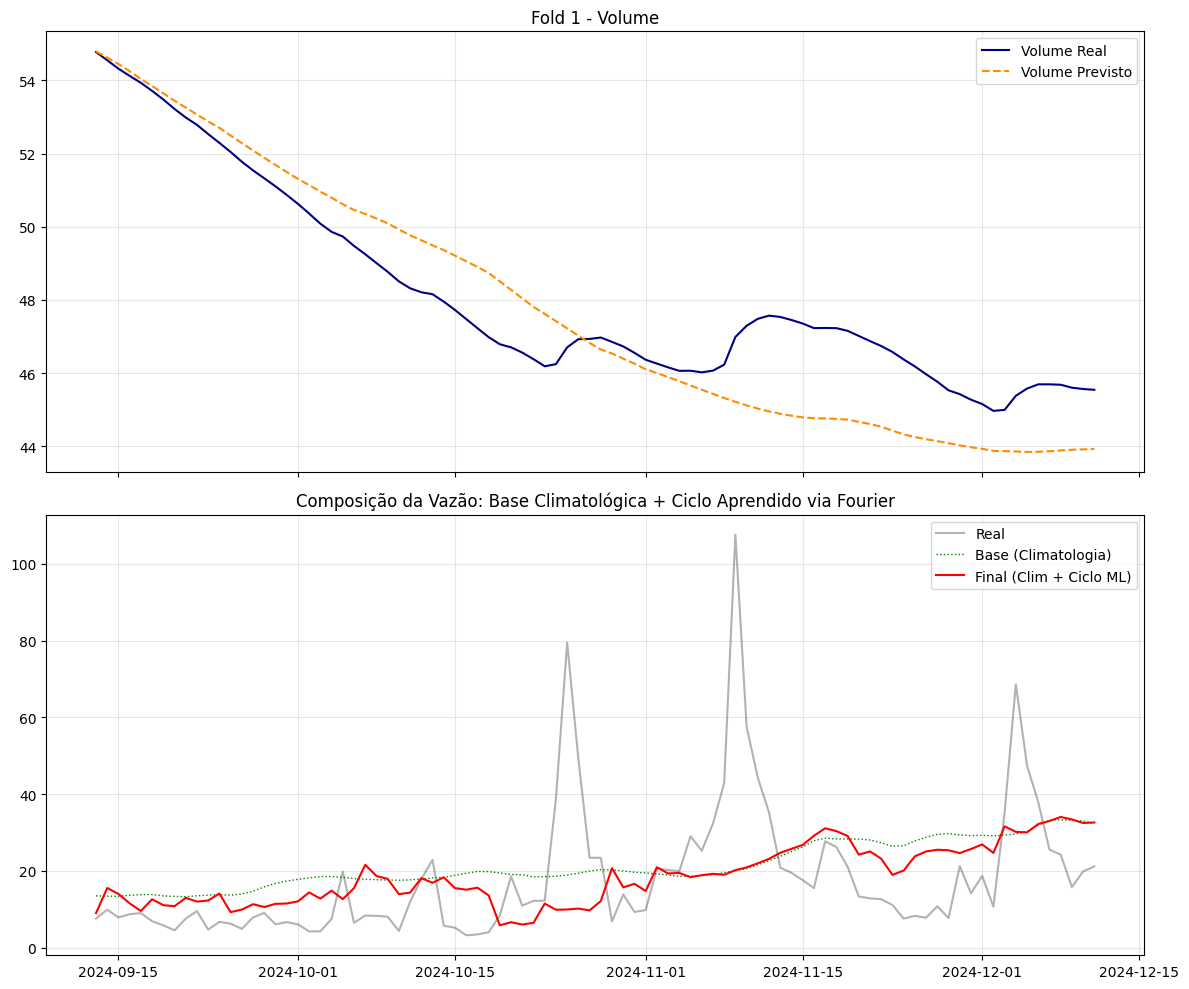

Fold 2 | RMSE Volume: 2.8377 | RMSE Vazão: 32.8850


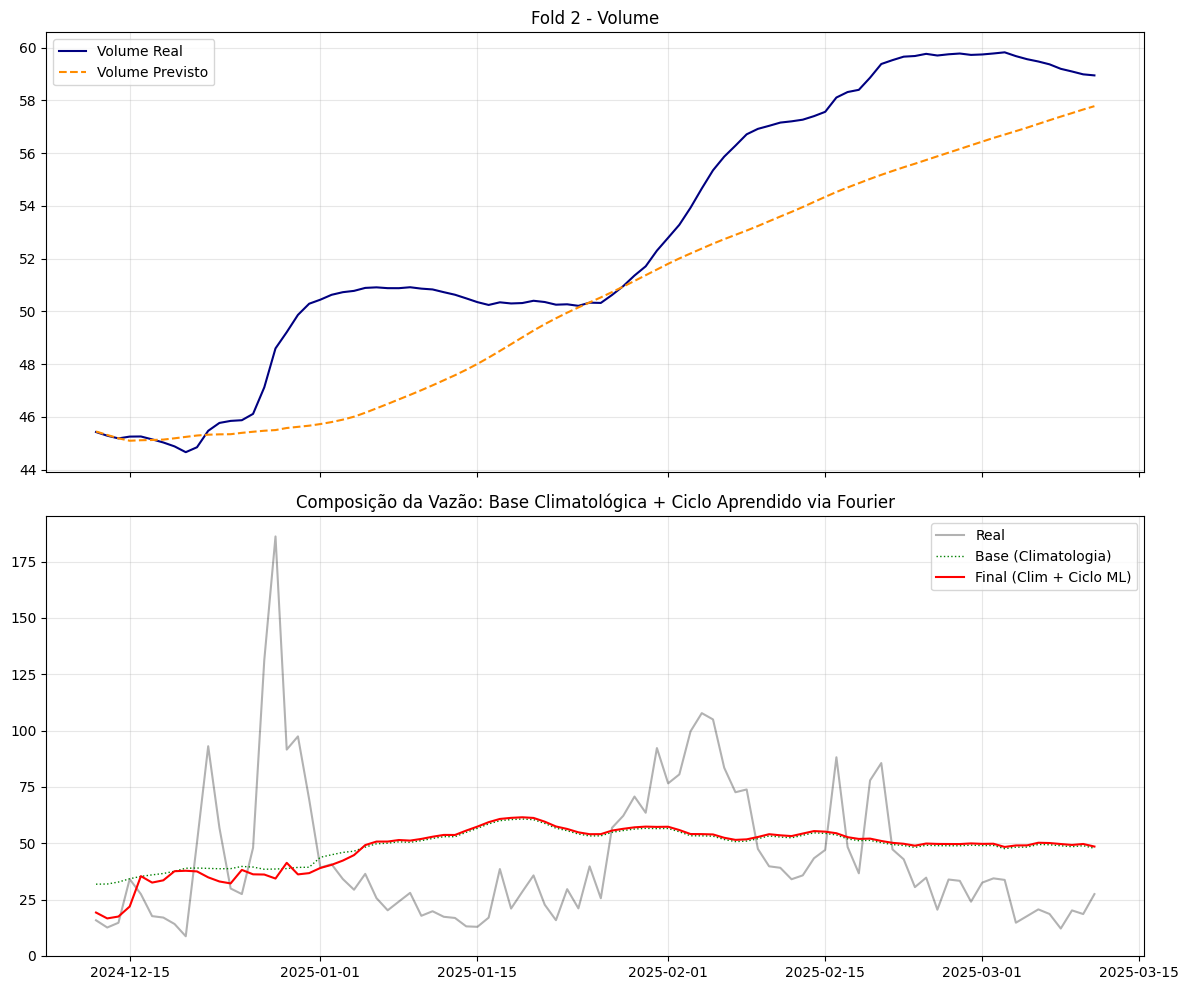

Fold 3 | RMSE Volume: 0.7986 | RMSE Vazão: 11.3526


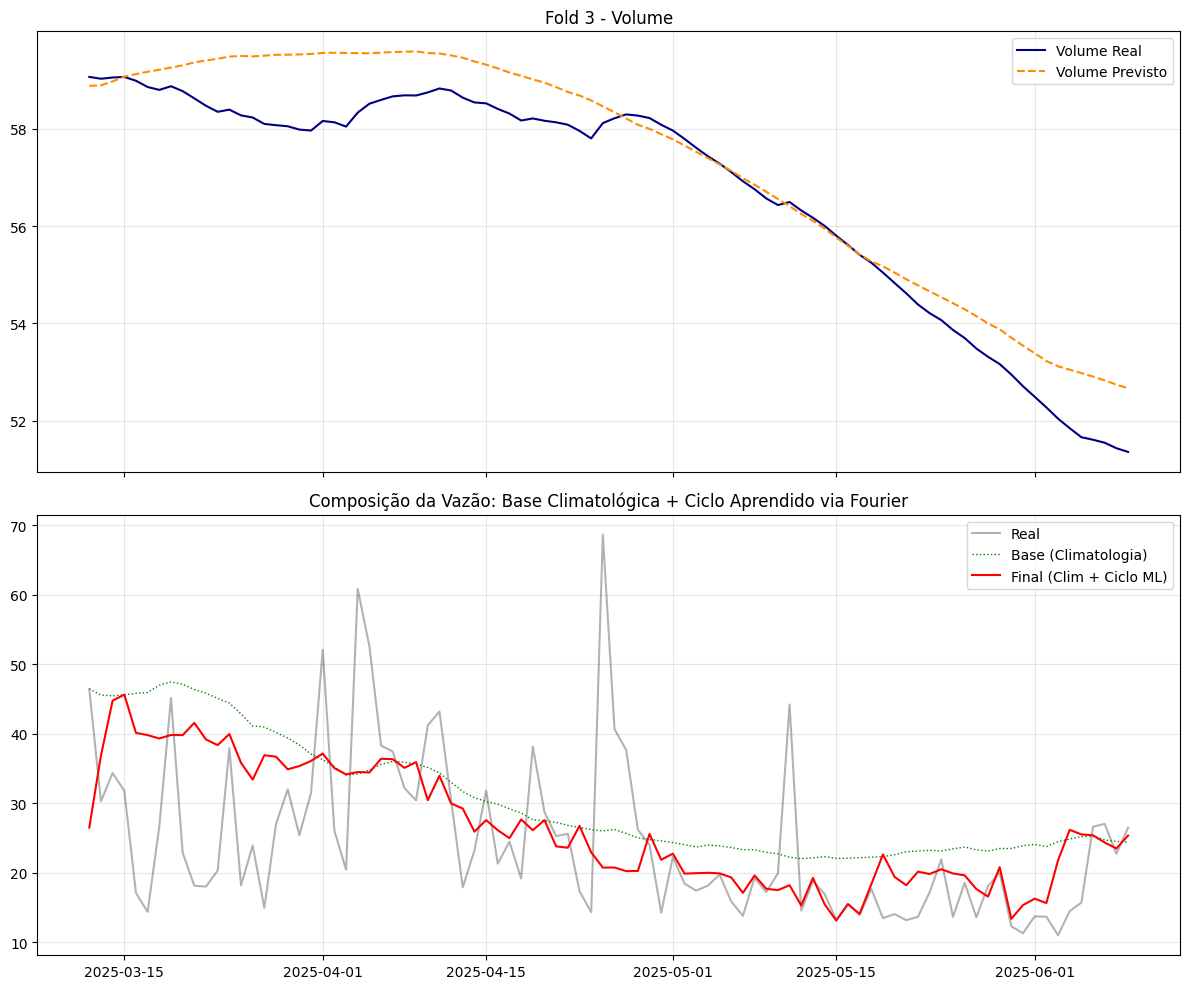

Fold 4 | RMSE Volume: 3.0466 | RMSE Vazão: 5.3382


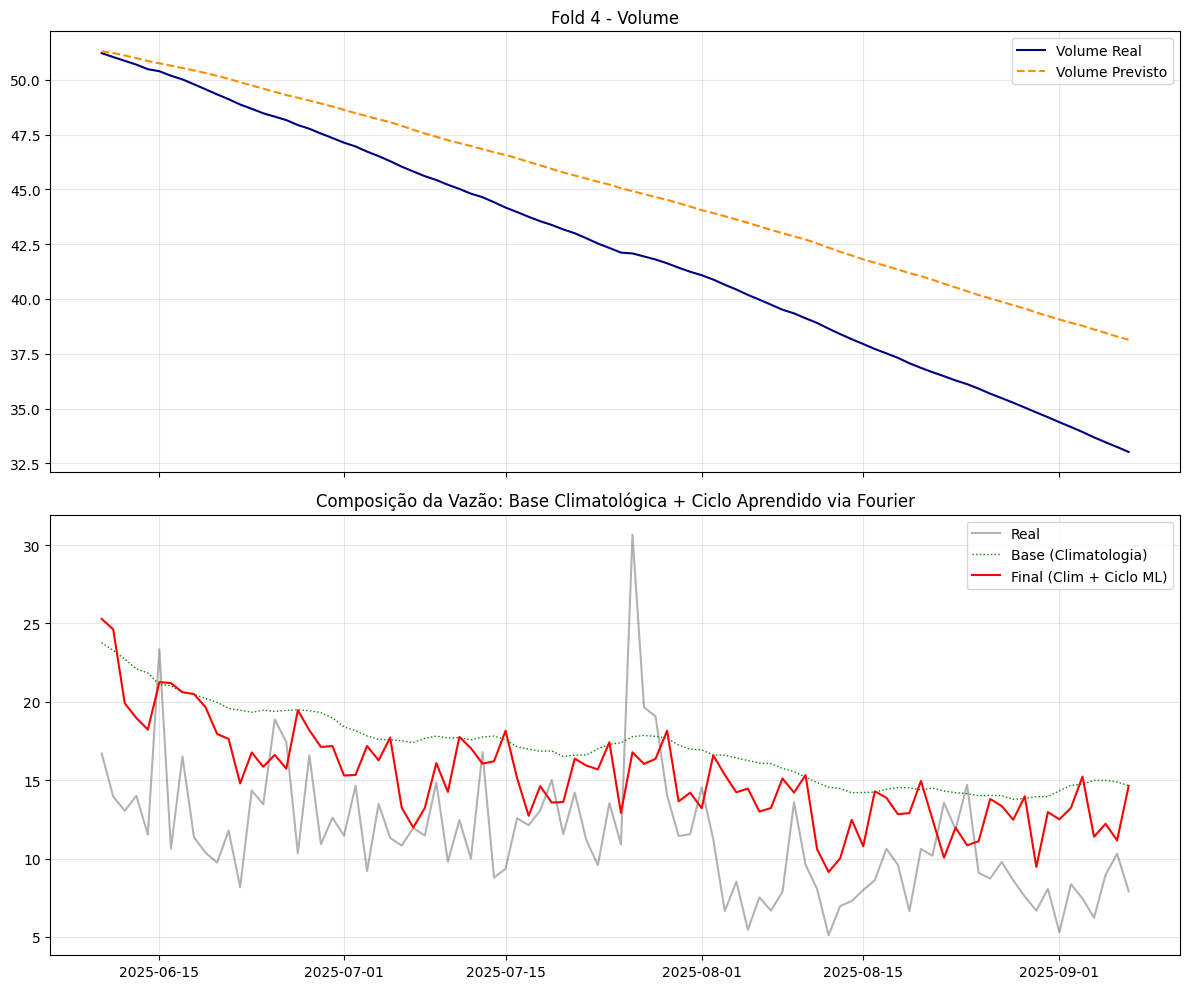

Fold 5 | RMSE Volume: 2.7465 | RMSE Vazão: 11.8020


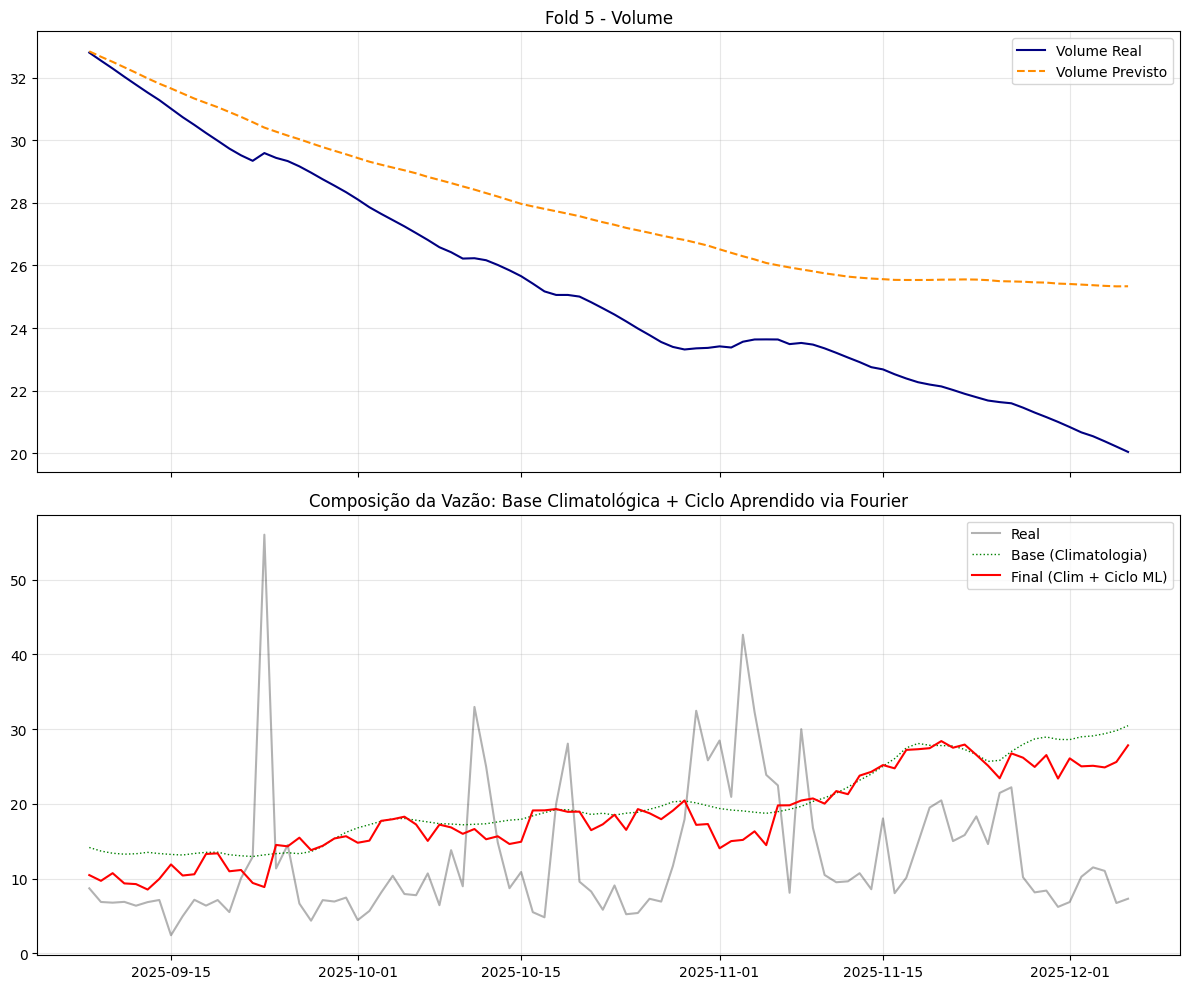


RMSE Médio (Volume): 2.1685


In [34]:


# ==============================================================================
# 2. MODELO MATEMÁTICO (PARA EXTRAIR O CICLO/RESÍDUO)
# ==============================================================================
# ==============================================================================
# 5. LOOP DE VALIDAÇÃO
# ==============================================================================
tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)
resultados_vol = []
resultados_vazao = []

print("=== INICIANDO MODELO: RESÍDUO DE FOURIER + BASE CLIMATOLÓGICA (COM SCALING) ===\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
    
    # --- A. TREINAMENTO ---
    
    # 1. Base Climatológica (Calculada no Treino)
    curva_clim = calcular_climatologia_robusta(df_train, nome_coluna_vazao_natural)
    
    # 2. Extração do Ciclo (Usando Modelo Matemático Fourier)
    model_math, serie_residuos_treino = treinar_modelo_extracao_residuo(df_train, nome_coluna_vazao_natural)
    # modelo sazonalidade + tendencia -> ytrue - ypred -> residuo -> outro modelo e depois somava os dois y_pred_resid
    # 3. Treino do ML no Ciclo
    model_ml_ciclo, last_resids_cycle = treinar_modelo_ciclo_ml(serie_residuos_treino)
    
    # 4. Treino do Volume (Retorna Modelo + Scaler)
    model_vol, scaler_vol = treinar_modelo_volume(df_train, nome_coluna_volume, nome_coluna_vazao_natural)
    
    # --- B. PREVISÃO RECURSIVA ---
    
    # Buffer para volume
    buffer_vols = list(df_train[nome_coluna_volume].tail(3).values)
    # Histórico para o ciclo (inicializado com os últimos resíduos REAIS do treino)
    hist_resid_cycle = list(last_resids_cycle)
    
    preds_vol = []
    preds_vazao_hibrida = [] 
    
    for i in range(len(df_test)):
        date = df_test.index[i]
        
        # 1. CALCULAR VAZÃO
        
        # A) Pega a Base (Climatologia)
        val_base_clim = get_clim_feature(pd.DatetimeIndex([date]), curva_clim)[0]
        
        # B) Prevê o Ciclo (Usando o ML treinado nos resíduos do Fourier)
        lags_cycle = np.array(hist_resid_cycle[-LAGS_CICLO:][::-1])
        cycle_pred = model_ml_ciclo.predict(pd.DataFrame([lags_cycle], columns=[f'lag_{k}' for k in range(1,LAGS_CICLO+1)]))[0]
        
        # C) SOMA HÍBRIDA: Climatologia + Ciclo(Fourier)
        if cycle_pred > 0:
            if cycle_pred - hist_resid_cycle[-1] > 0:
                cycle_pred = cycle_pred * 0.2  # Ajuste de escala do ciclo
            else:
                cycle_pred = cycle_pred * 0.8  # Ajuste de escala do ciclo
        vazao_final = val_base_clim + cycle_pred
        
        if vazao_final < 0: vazao_final = 0
        preds_vazao_hibrida.append(vazao_final)
        
        # Atualiza histórico de ciclo com o previsto (Recursão)
        hist_resid_cycle.append(cycle_pred)
        
        # 2. CALCULAR VOLUME
        vol_t1 = buffer_vols[-1]
        vol_diff = vol_t1 - buffer_vols[-2]
        
        # Cria DF com dados brutos
        input_vol = pd.DataFrame({
            'vol_lag1': [vol_t1],
            'vol_diff': [vol_diff],
            'vazao_input': [vazao_final]
        })
        
        # --- APLICA SCALING ---
        # Usa o scaler treinado para transformar os dados brutos na escala correta
        input_vol_scaled = scaler_vol.transform(input_vol)
        
        # Prevê
        pred_vol = model_vol.predict(input_vol_scaled)[0]
        preds_vol.append(pred_vol)
        
        buffer_vols.append(pred_vol)
        buffer_vols.pop(0)

    # --- AVALIAÇÃO ---
    rmse_vol = np.sqrt(mean_squared_error(df_test[nome_coluna_volume], preds_vol))
    rmse_vazao = np.sqrt(mean_squared_error(df_test[nome_coluna_vazao_natural], preds_vazao_hibrida))
    
    resultados_vol.append(rmse_vol)
    
    print(f"Fold {fold+1} | RMSE Volume: {rmse_vol:.4f} | RMSE Vazão: {rmse_vazao:.4f}")
    plots_duplo(df_test, preds_vol, preds_vazao_hibrida, curva_clim, fold)
    
    
print(f"\nRMSE Médio (Volume): {np.mean(resultados_vol):.4f}")

### FIM